# University Website Quality Scoring and Ranking

**Machine Learning Laboratory — CSE 4112**
Department of Computer Science and Engineering
Khulna University of Engineering & Technology

---

## What this notebook does

Given the measurable attributes of a university's landing page, predict a **website quality
score from 0 to 100** — higher is better — and rank 1,225 universities globally, by region
and by country.

**All 22 Bangladeshi universities are held out of training entirely** and used as an unseen
case study in §9, so every number reported for them is an honest prediction.

```
    INPUT                        MODEL                    OUTPUT
 71 measured           ->   trained regressor    ->   score 0-100
 attributes of                                        grade A+ .. F
 one landing page                                     global / regional / country rank
```

## How the notebook is organised

| § | Section | What it establishes |
|---|---|---|
| 1 | Data and the feature catalogue | 1,225 universities, 71 attributes, how each one is classified |
| 2 | Exploration | what the attributes look like, what is missing and why |
| 3 | The scoring model | the seven equations that define the target, term by term |
| 4 | Train / test split | 80 / 20 stratified, **with all 22 Bangladeshi universities held out** |
| 5 | **Model comparison** | twelve algorithms on identical data — the main experiment |
| 6 | Cross-validation | confirming the ranking of models is not a fluke of one split |
| 7 | Tuning | grid search on the winner |
| 8 | Held-out evaluation | the final honest number |
| 9 | **Bangladesh case study** | 22 universities the model never saw, predicted and compared |
| 10 | Why models differ | error analysis — the result worth presenting |
| 11 | Feature importance | what actually drives a website's score |
| 12 | Sensitivity and ablation | how much of the ranking is the websites, how much is our weights |
| 13 | Rankings | global, regional, country |
| 14 | **Look up any university** | interactive |
| 15 | **Score a new university** | interactive |
| 16 | Conclusions and limitations | |

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (ExtraTreesRegressor, GradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})

HERE = Path.cwd()
BASE = HERE.parent if HERE.name == "notebook" else HERE
DATA = BASE / "data"

print(f"project root : {BASE}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | lightgbm {lgb.__version__}")

project root : C:\Users\USER\OneDrive\Desktop\ML_last\ml-project\FINAL_PROJECT
numpy 2.4.4 | pandas 2.3.3 | lightgbm 4.6.0


---
# 1. The data

The raw crawl covered 1,230 university landing pages with 85 columns. Cleaning is performed
by `src/build_dataset.py` and is fully reproducible; the log below is what it did.

| step | effect |
|---|---|
| dropped constant / empty columns | `ok`, `extractor_version`, `render_error` |
| dropped an exact duplicate column | `a62_load_speed_s` was identical to `load_time_s` |
| dropped external ranking *values* | 95–99% missing, and they describe the institution, not the site |
| merged duplicate sites | 5 universities reached through two entry URLs each → 1,225 rows |
| censored impossible dates | 284 notice dates fell *after* the crawl date |
| flagged regional buckets | 169 rows have a region in the `country` field, not a country |

The three CSV files below are the entire dataset.

In [2]:
full = pd.read_csv(DATA / "university_website_scores.csv")
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
ddict = pd.read_csv(DATA / "data_dictionary.csv")
summary = json.loads((DATA / "dataset_summary.json").read_text(encoding="utf-8"))

META = ["uni_id", "name", "url", "country", "region", "rank", "regional_rank", "country_rank"]
TARGET = "website_score"
FEATURES = [c for c in train.columns if c not in META + [TARGET, "grade"]]

print(f"all universities : {len(full):,} rows x {len(FEATURES)} features")
print(f"training set     : {len(train):,} rows  ({len(train)/len(full):.0%})")
print(f"test set         : {len(test):,} rows  ({len(test)/len(full):.0%})")
print(f"\nno overlap between train and test: {len(set(train.uni_id) & set(test.uni_id)) == 0}")
full.head(4)[["rank", "name", "country", "a37_programs_listing",
              "a34_department_links", "a03_nav_item_count", "website_score", "grade"]]

all universities : 1,225 rows x 71 features
training set     : 981 rows  (80%)
test set         : 244 rows  (20%)

no overlap between train and test: True


,rank,name,country,a37_programs_listing,a34_department_links,a03_nav_item_count,website_score,grade
0,1,Eotvos Lorand University,Hungary,1,1,5,94.94,A+
1,2,University of New England,Australia,1,1,6,94.36,A+
2,3,University of Strasbourg,France,1,1,6,93.72,A+
3,4,University of Porto,Portugal,1,1,5,93.36,A+


## The feature catalogue: how every attribute is classified

Each of the 71 features is classified on **three independent axes**, and `build_dataset.py`
writes all three to `data/feature_catalog.csv`:

| axis | question it answers | values |
|---|---|---|
| **source group** | *where on the page did the extractor find it?* | 12 groups: header & navigation, rankings & recognition, notices & updates, events & media, page content, footer, visual design, service & interaction, technical performance, SEO & metadata, accessibility, measurement quality |
| **scoring role** | *which dimension of the target consumes it, with what weight, through what transform?* | $D_1 \ldots D_7$, or "not scored" |
| **measurement type** | *what kind of number is it?* | binary flag, count, percentage, ratio, index, z-score, log-count, indicator |

The three axes are genuinely independent, and the second one is the important one for this
project. **20 of the 71 features are observed but do not enter the score at all, each for a recorded reason.** They are
still given to every model. That is deliberate: the model has to work out which attributes
matter, rather than being handed a shortened list that already encodes the answer.

In [3]:
cat = pd.read_csv(DATA / "feature_catalog.csv")

print(f"{len(cat)} features   |   {(cat.scored_by != '--').sum()} enter the score   |   "
      f"{(cat.scored_by == '--').sum()} observed but unscored\n")

pivot = pd.crosstab(cat.source_group, cat.scored_by)
pivot["TOTAL"] = pivot.sum(axis=1)
print("features by source group (columns) x scoring dimension:\n")
print(pivot.to_string())

print("\nby measurement type:")
for k, v in cat.measurement_type.value_counts().items():
    print(f"  {k:<26}{v:>3}")

71 features   |   51 enter the score   |   20 observed but unscored

features by source group (columns) x scoring dimension:

scored_by               --  D1  D2  D3  D4  D5  D6  D7  TOTAL
source_group                                                 
Accessibility            1   0   0   0   0   3   0   0      4
Events & media           6   0   0   3   0   0   0   0      9
Footer                   0   0   0   1   2   0   0   2      5
Header & navigation      0   0   0   0   4   1   0   1      6
Measurement quality      3   0   0   0   0   0   0   0      3
Notices & updates        0   0   1   5   0   0   0   0      6
Page content             0   6   5   0   0   0   0   4     15
Rankings & recognition   5   0   0   0   0   0   0   2      7
SEO & metadata           0   0   0   0   0   0   3   0      3
Service & interaction    2   0   1   0   0   0   0   1      4
Technical performance    1   0   0   0   0   1   4   0      6
Visual design            2   0   0   0   0   1   0   0      3

by me

The 51 scored features, with the exact weight each carries inside its dimension and the
number of points it is worth at its maximum. These 35 rows *are* the scoring model — §3
writes the same information as equations.

In [4]:
sc = cat[cat.scored_by != "--"].sort_values(["scored_by", "points_at_maximum"],
                                            ascending=[True, False])
print(sc[["feature", "scored_by", "weight_in_dimension", "points_at_maximum",
          "measurement_type", "transform"]].to_string(index=False))
print(f"\npoints accounted for: {sc.points_at_maximum.sum():.0f} / 100")

               feature scored_by  weight_in_dimension  points_at_maximum        measurement_type                                       transform
  a37_programs_listing        D1                 0.30               8.40             binary flag                                  identity (0/1)
  a34_department_links        D1                 0.25               7.00             binary flag                                  identity (0/1)
      a35_faculty_link        D1                 0.15               4.20             binary flag                                  identity (0/1)
      a39_library_link        D1                 0.12               3.36             binary flag                                  identity (0/1)
a36_research_highlight        D1                 0.10               2.80             binary flag                                  identity (0/1)
       a40_career_link        D1                 0.08               2.24             binary flag                                  

And the 20 features the scoring model never looks at, with the reason each is excluded.
Several of them correlate with the
score anyway — a site that has a live chat widget tends to be a site that has everything
else too — which is exactly why leaving them in the model's input is not free: the model
has to distinguish a cause from a companion.

In [5]:
un = cat[cat.scored_by == "--"].sort_values("corr_with_score", ascending=False)
print(un[["feature", "source_group", "corr_with_score", "transform"]]
      .rename(columns={"transform": "reason for exclusion"})
      .to_string(index=False))

                        feature           source_group  corr_with_score                                             reason for exclusion
                   a28_contests         Events & media            0.289          engagement signal; serves no applicant information need
              a09_national_rank Rankings & recognition            0.267           prestige display; excluded to prevent prestige leakage
               a61_testimonials  Service & interaction            0.213                  marketing; serves no applicant information need
             a26_event_captions         Events & media            0.211           media richness; presence is measurable, quality is not
               a25_event_images         Events & media            0.192           media richness; presence is measurable, quality is not
               a12_accred_count Rankings & recognition            0.188                count depth of a badge already scored by presence
              a30_image_gallery         E

---
# 2. Exploring the data

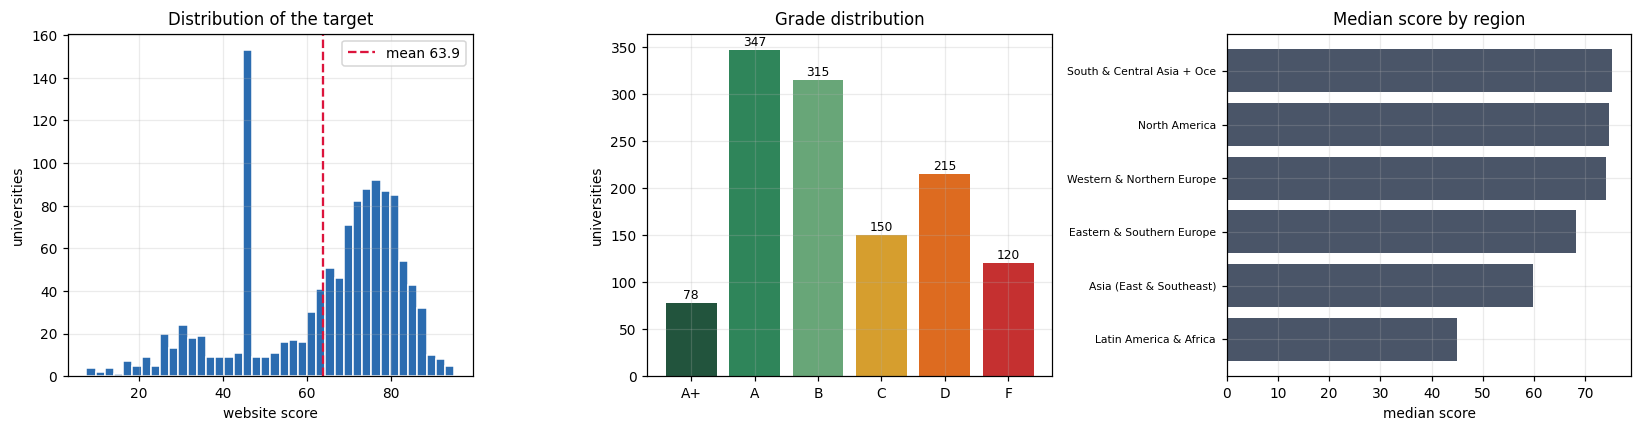

count    1225.00
mean       63.86
std        18.46
min         7.59
25%        45.00
50%        70.02
75%        77.82
max        94.94


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(full.website_score, bins=40, color="#2b6cb0", edgecolor="white")
ax[0].axvline(full.website_score.mean(), color="crimson", ls="--", lw=1.5,
              label=f"mean {full.website_score.mean():.1f}")
ax[0].set_xlabel("website score"); ax[0].set_ylabel("universities")
ax[0].set_title("Distribution of the target"); ax[0].legend()

order = ["A+", "A", "B", "C", "D", "F"]
gc = full.grade.value_counts().reindex(order)
ax[1].bar(order, gc.values, color=["#22543d", "#2f855a", "#68a678", "#d69e2e", "#dd6b20", "#c53030"])
for i, v in enumerate(gc.values):
    ax[1].text(i, v + 5, str(v), ha="center", fontsize=8)
ax[1].set_title("Grade distribution"); ax[1].set_ylabel("universities")

reg = full.groupby("region").website_score.median().sort_values()
ax[2].barh(range(len(reg)), reg.values, color="#4a5568")
ax[2].set_yticks(range(len(reg)))
ax[2].set_yticklabels([r[:26] for r in reg.index], fontsize=7)
ax[2].set_xlabel("median score"); ax[2].set_title("Median score by region")
plt.tight_layout(); plt.show()

print(full.website_score.describe().round(2).to_string())

The target has a long left tail and a visible shoulder around 45. That shoulder is not an
artefact — it is the population of sites that hit a **scoring gate** (§3), and it is the
structure that separates the model families in §5.

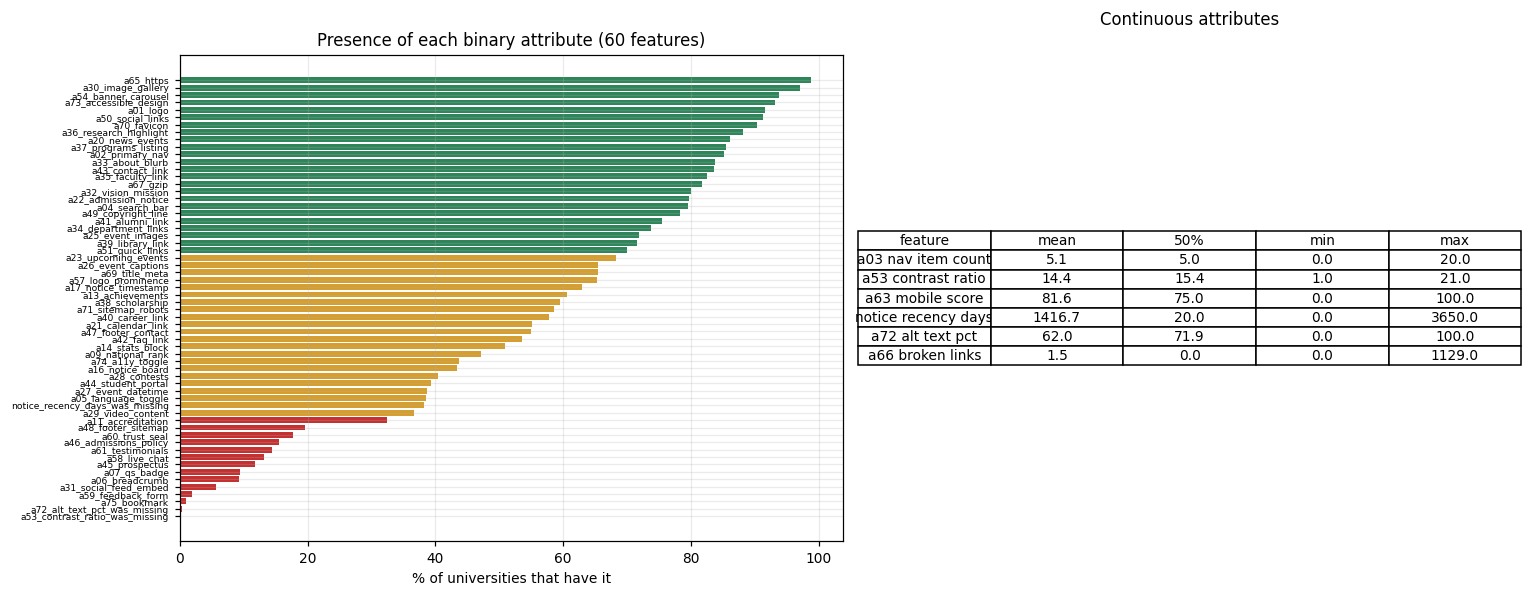

In [7]:
binaries = [c for c in FEATURES if full[c].dropna().isin([0, 1]).all() and full[c].nunique() == 2]
prev = full[binaries].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ["#c53030" if v < 0.35 else "#d69e2e" if v < 0.7 else "#2f855a" for v in prev.values]
ax[0].barh(range(len(prev)), prev.values * 100, color=colors)
ax[0].set_yticks(range(len(prev))); ax[0].set_yticklabels(prev.index, fontsize=6)
ax[0].set_xlabel("% of universities that have it")
ax[0].set_title(f"Presence of each binary attribute ({len(prev)} features)")

num = ["a03_nav_item_count", "a53_contrast_ratio", "a63_mobile_score",
       "notice_recency_days", "a72_alt_text_pct", "a66_broken_links"]
ax[1].axis("off")
tbl = full[num].describe().T[["mean", "50%", "min", "max"]].round(1)
tbl.insert(0, "feature", [n.replace("_", " ") for n in tbl.index])
ax[1].table(cellText=tbl.values, colLabels=tbl.columns, loc="center", cellLoc="center"
            ).auto_set_font_size(False)
ax[1].set_title("Continuous attributes", pad=20)
plt.tight_layout(); plt.show()

## Missing values: absence has a direction

Three attributes are missing for some sites, and the standard fix — replace with the median
— is wrong for all three.

The clearest case is `notice_recency_days`. Its median is **1 day**. Median-filling would
therefore record the **468 universities with no dated notice anywhere on the site** as
having posted something *yesterday*, handing the strongest freshness signal in the dataset
to exactly the sites that earned it least. Absence would be read as average when it means
*absent*.

Each of the three is filled at its **worst defensible value** instead, and a companion
`*_was_missing` flag is computed first, so "this was never measured" stays recoverable.

In [8]:
policy = json.loads((DATA / "missing_value_policy.json").read_text(encoding="utf-8"))
print(f"{'attribute':<26}{'rows':>6}{'filled with':>13}{'median would be':>17}   meaning of absence")
for k, v in policy.items():
    print(f"{k:<26}{v['n_filled']:>6}{v['fill_value']:>13.1f}{v['median_would_have_been']:>17.1f}"
          f"   {v['reason'].split('->')[0].strip()}")

attribute                   rows  filled with  median would be   meaning of absence
notice_recency_days          468       3650.0              1.0   no dated notice exists anywhere
a72_alt_text_pct               4          0.0             72.0   no image carries a text alternative
a53_contrast_ratio             1          1.0             15.4   no readable text block was found


---
# 3. The scoring model

The dataset records what a website *has*. It does not record how good it is, so a scoring
model was defined to turn attributes into a score. It is built around one question:

> **What does a prospective student need from a university website?**

Seven dimensions answer that question. Each is a sub-score in $[0, 1]$ built from named
attributes; the website score is their weighted sum, subject to two gates:

$$
\text{Score} \;=\; \min\Bigl(\textstyle\sum_{k=1}^{7} w_k D_k,\; \text{cap}\Bigr)
$$

| | Dimension | Weight | What it asks |
|---|---|---|---|
| $D_1$ | Academic information | **28** | What can I study, and who teaches it? |
| $D_2$ | Admission support | **22** | How do I apply, and what will it cost? |
| $D_3$ | Currency and activity | **15** | Is this institution alive and current? |
| $D_4$ | Navigation and findability | **15** | Can I find what I need? |
| $D_5$ | Usability and accessibility | **10** | Can I use it, on any device? |
| $D_6$ | Technical quality and discoverability | **7** | Does it work, and can it be found? |
| $D_7$ | Institutional identity and transparency | **3** | Is it clear who they are? |

The weights are ordered by how directly each dimension serves the applicant's task.
Content a student came for carries half the score ($D_1 + D_2 = 50$); the machinery that
delivers it carries most of the rest; self-presentation carries the least.

### Two gates

Some failures are severe enough to cap the score regardless of everything else:

* **no primary navigation → score capped at 45.** A site that cannot be navigated cannot
  serve an applicant, however much content is buried in it.
* **no HTTPS → score capped at 60.** A site that is not encrypted should not be trusted
  with an application form.

### The seven dimensions, written out

Each $D_k$ is a weighted sum of named attributes, with the inner weights summing to 1 so
that $D_k \in [0,1]$ and dimension $k$ can contribute at most $w_k$ points. $g(a)$ denotes
attribute $a$ read as $0/1$; the named functions are the response curves plotted below.

$$
D_1 = 0.30\,g(\text{programs}) + 0.25\,g(\text{departments}) + 0.15\,g(\text{faculty})
     + 0.12\,g(\text{library}) + 0.10\,g(\text{research}) + 0.08\,g(\text{careers})
$$
$$
D_2 = 0.26\,g(\text{admissions policy}) + 0.20\,g(\text{admission notice})
     + 0.18\,g(\text{scholarship}) + 0.15\,g(\text{contact}) + 0.12\,g(\text{prospectus})
     + 0.06\,g(\text{FAQ}) + 0.03\,g(\text{live chat})
$$
$$
D_3 = 0.32\,f_{\text{rec}}(\text{notice age}) + 0.20\,f_{\text{evt}}(\text{events, dated})
     + 0.16\,g(\text{news}) + 0.12\,g(\text{calendar}) + 0.08\,g(\text{notice board})
     + 0.06\,g(\text{timestamp}) + 0.04\,g(\text{upcoming events})
     + 0.02\,g(\text{last-updated line})
$$
$$
D_4 = 0.25\,g(\text{primary nav}) + 0.25\,f_{\text{nav}}(\text{menu items})
     + 0.20\,g(\text{search}) + 0.10\,g(\text{breadcrumb}) + 0.10\,g(\text{quick links})
     + 0.10\,g(\text{footer sitemap})
$$
$$
D_5 = 0.32\,\tfrac{\text{mobile}}{100} + 0.23\,f_{\text{con}}(\text{contrast})
     + 0.18\,\sqrt{\tfrac{\text{alt-text}}{100}} + 0.10\,g(\text{accessible design})
     + 0.09\,g(\text{language toggle}) + 0.08\,g(\text{a11y toggle})
$$
$$
D_6 = 0.26\,g(\text{https}) + 0.24\,f_{\text{brk}}(\text{broken links})
     + 0.20\,\bigl(1 - \text{pctl}_{\text{region}}(\text{load time})\bigr)
     + 0.12\,g(\text{title \& meta}) + 0.07\,g(\text{gzip})
     + 0.07\,g(\text{sitemap/robots}) + 0.04\,g(\text{favicon})
$$
$$
D_7 = 0.20\,g(\text{vision}) + 0.14\,g(\text{about}) + 0.14\,g(\text{footer contact})
     + 0.11\,g(\text{accreditation}) + 0.11\,g(\text{student portal})
     + 0.10\,g(\text{alumni}) + 0.08\,g(\text{achievements}) + 0.06\,g(\text{logo})
     + 0.04\,g(\text{social links}) + 0.02\,g(\text{trust seal})
$$

Every inner weight above is the `weight_in_dimension` column of the feature catalogue, so
the equations and the code cannot drift apart.

### Which attributes the label does *not* use, and why

**51 of the 71 features enter the label. The other 20 do not**, and every one of them has a
recorded reason -- printed in the `transform` column of the catalogue and reproduced in the
report's exclusion register. They fall into seven groups:

| reason | n | examples |
|---|---|---|
| prestige leakage | 2 | `a07_qs_badge`, `a09_national_rank` |
| quality not judgeable from presence | 7 | `a30_image_gallery`, `a54_banner_carousel` |
| no applicant information need | 3 | `a14_stats_block`, `a61_testimonials` |
| depth count of a scored presence | 2 | `a12_accred_count`, `a15_stat_item_count` |
| too rare to carry weight | 2 | `a59_feedback_form` (1.9%), `a75_bookmark` (1.0%) |
| redundant with a scored attribute | 1 | `broken_links_log` |
| measurement metadata | 3 | the three `*_was_missing` indicators |

All 71 are still supplied to every model as input; only the *target* omits these 20.

### Non-linear response curves

Six attributes do not reward linearly, and the scoring model says so explicitly. These
curves are the reason §5 finds a real difference between model families.

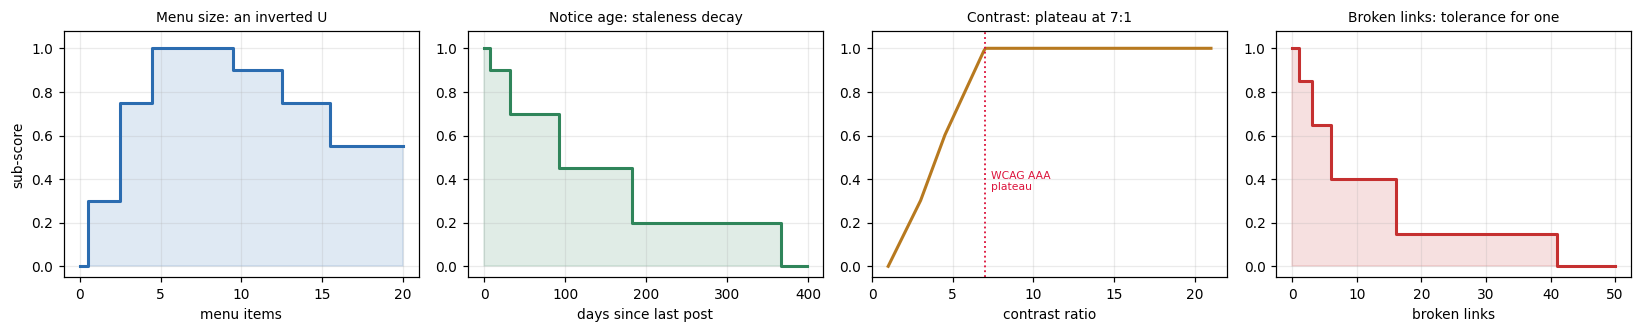

Why these shapes matter for the modelling:

  menu size   a 20-item menu is a wall of links, not better navigation than a 7-item menu.
              No monotone (always-increasing) function can express that.
  notice age  a post from last week and one from last year are not 51 weeks apart in value;
              both "recent" and "abandoned" are plateaus with a cliff between them.
  contrast    WCAG AAA is 7:1. Beyond it, more contrast is not a better reading experience,
              so the curve stops rewarding rather than continuing upward.
  broken      one dead link is an oversight, forty is neglect. The penalty is not linear
  links       in the count.


In [9]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.1))

n = np.arange(0, 21)
nav = np.where(n <= 0, 0, np.where(n <= 2, .3, np.where(n <= 4, .75,
      np.where(n <= 9, 1., np.where(n <= 12, .9, np.where(n <= 15, .75, .55))))))
ax[0].step(n, nav, where="mid", color="#2b6cb0", lw=2)
ax[0].fill_between(n, nav, step="mid", alpha=.15, color="#2b6cb0")
ax[0].set_title("Menu size: an inverted U", fontsize=9)
ax[0].set_xlabel("menu items"); ax[0].set_ylabel("sub-score")

d = np.arange(0, 400, 2)
rec = np.where(d <= 7, 1., np.where(d <= 30, .9, np.where(d <= 90, .7,
      np.where(d <= 180, .45, np.where(d <= 365, .2, 0.)))))
ax[1].step(d, rec, where="post", color="#2f855a", lw=2)
ax[1].fill_between(d, rec, step="post", alpha=.15, color="#2f855a")
ax[1].set_title("Notice age: staleness decay", fontsize=9); ax[1].set_xlabel("days since last post")

r = np.linspace(1, 21, 200)
con = np.where(r < 3, (r - 1) / 2 * .3, np.where(r < 4.5, .3 + (r - 3) / 1.5 * .3,
      np.where(r < 7, .6 + (r - 4.5) / 2.5 * .4, 1.)))
ax[2].plot(r, con, color="#b7791f", lw=2)
ax[2].axvline(7, color="crimson", ls=":", lw=1.2)
ax[2].text(7.4, .35, "WCAG AAA\nplateau", fontsize=7, color="crimson")
ax[2].set_title("Contrast: plateau at 7:1", fontsize=9); ax[2].set_xlabel("contrast ratio")

b = np.arange(0, 51)
bro = np.where(b <= 0, 1., np.where(b <= 2, .85, np.where(b <= 5, .65,
      np.where(b <= 15, .4, np.where(b <= 40, .15, 0.)))))
ax[3].step(b, bro, where="post", color="#c53030", lw=2)
ax[3].fill_between(b, bro, step="post", alpha=.15, color="#c53030")
ax[3].set_title("Broken links: tolerance for one", fontsize=9); ax[3].set_xlabel("broken links")

for a in ax:
    a.set_ylim(-.05, 1.08)
plt.tight_layout(); plt.show()

print("""Why these shapes matter for the modelling:

  menu size   a 20-item menu is a wall of links, not better navigation than a 7-item menu.
              No monotone (always-increasing) function can express that.
  notice age  a post from last week and one from last year are not 51 weeks apart in value;
              both "recent" and "abandoned" are plateaus with a cliff between them.
  contrast    WCAG AAA is 7:1. Beyond it, more contrast is not a better reading experience,
              so the curve stops rewarding rather than continuing upward.
  broken      one dead link is an oversight, forty is neglect. The penalty is not linear
  links       in the count.""")

## What the scoring model produced

scoring gates applied to 186 of 1225 universities (15.2%)

  no primary navigation (cap 45) :  182
  no HTTPS              (cap 60) :   14


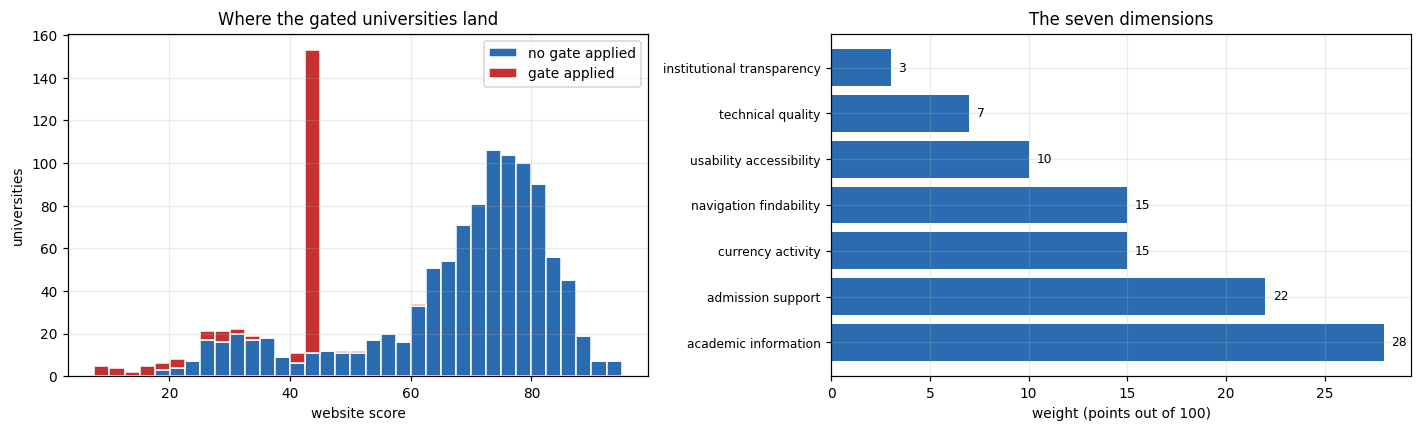

In [10]:
DIMS = {"D1_academic_information": 28, "D2_admission_support": 22, "D3_currency_activity": 15,
        "D4_navigation_findability": 15, "D5_usability_accessibility": 10,
        "D6_technical_quality": 7, "D7_institutional_transparency": 3}

gated = ((full.a02_primary_nav == 0) | (full.a65_https == 0))
print(f"scoring gates applied to {gated.sum()} of {len(full)} universities "
      f"({gated.mean():.1%})\n")
print(f"  no primary navigation (cap 45) : {(full.a02_primary_nav == 0).sum():>4}")
print(f"  no HTTPS              (cap 60) : {(full.a65_https == 0).sum():>4}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist([full.website_score[~gated], full.website_score[gated]], bins=35, stacked=True,
           color=["#2b6cb0", "#c53030"], edgecolor="white",
           label=["no gate applied", "gate applied"])
ax[0].set_xlabel("website score"); ax[0].set_ylabel("universities")
ax[0].set_title("Where the gated universities land"); ax[0].legend()

w = pd.Series(DIMS)
ax[1].barh(range(len(w)), w.values, color="#2b6cb0")
ax[1].set_yticks(range(len(w)))
ax[1].set_yticklabels([k.split("_", 1)[1].replace("_", " ") for k in w.index], fontsize=8)
ax[1].set_xlabel("weight (points out of 100)")
ax[1].set_title("The seven dimensions")
for i, v in enumerate(w.values):
    ax[1].text(v + .4, i, str(v), va="center", fontsize=8)
plt.tight_layout(); plt.show()

### Verifying the arithmetic

`data/dimension_scores.csv` holds, for every university, the seven sub-scores, the points
each contributed, the uncapped total, the cap that applied and the final score. Every
published score can therefore be recomputed by hand. Here it is checked for all 1,225.

In [11]:
dims = pd.read_csv(DATA / "dimension_scores.csv")
DIMCOLS = [c for c in dims.columns if c[0] == "D" and c[1].isdigit()]
w_vec = np.array(list(DIMS.values()), float)

recomputed = np.minimum(dims[DIMCOLS].values @ w_vec, dims.cap.values).round(2)
print(f"scores recomputed from the seven sub-scores match the published score for "
      f"{np.isclose(recomputed, dims.website_score, atol=0.01).mean():.1%} of universities")

ex = dims[dims.name.str.contains("Khulna University of Engineering", na=False)].iloc[0]
print(f"\nworked example — {ex['name']}\n" + "-" * 58)
for c in DIMCOLS:
    print(f"  {c[:2]}  sub-score {ex[c]:.3f}  x weight {DIMS[c]:>2}  =  {ex['pts_' + c[:2]]:>6.2f} points")
print(f"  {'':4}{'uncapped total':<34}{ex.raw_score:>8.2f}")
print(f"  {'':4}{'cap in force':<34}{ex.cap:>8.2f}")
print(f"  {'':4}{'PUBLISHED SCORE':<34}{ex.website_score:>8.2f}   grade {ex.grade}")

print(f"\ngates: {int(dims.gate_nav.sum())} universities capped at 45 for having no primary "
      f"navigation, {int(dims.gate_https.sum())} capped at 60 for no HTTPS")
print(f"points destroyed by the gates: {dims.points_lost_to_gate.sum():,.0f} across "
      f"{int((dims.points_lost_to_gate > 0).sum())} universities "
      f"(mean {dims[dims.points_lost_to_gate > 0].points_lost_to_gate.mean():.1f} each)")

scores recomputed from the seven sub-scores match the published score for 100.0% of universities

worked example — Khulna University of Engineering and Technology
----------------------------------------------------------
  D1  sub-score 0.920  x weight 28  =   25.76 points
  D2  sub-score 0.850  x weight 22  =   18.70 points
  D3  sub-score 0.908  x weight 15  =   13.62 points
  D4  sub-score 0.600  x weight 15  =    9.00 points
  D5  sub-score 0.749  x weight 10  =    7.49 points
  D6  sub-score 0.707  x weight  7  =    4.95 points
  D7  sub-score 0.890  x weight  3  =    2.67 points
      uncapped total                       82.18
      cap in force                        100.00
      PUBLISHED SCORE                      82.18   grade A

gates: 182 universities capped at 45 for having no primary navigation, 14 capped at 60 for no HTTPS
points destroyed by the gates: 2,652 across 141 universities (mean 18.8 each)


---
# 4. Train / test split

**80% train, 20% test**, stratified on score band so both halves span the full quality
range, with a fixed seed so the split is reproducible — **and with one constraint added on
top**:

> **Every Bangladeshi university is in the test set. None is used for training.**

There are two reasons for the constraint.

1. **The case study in §9 has to mean one thing.** The report presents a table of all 22
   Bangladeshi universities with predicted and actual scores. If some of them had been in
   the training set, half that table would be a memory and half a prediction, and the two
   would not be comparable row to row. Holding the whole country out makes every row an
   honest out-of-sample prediction.
2. **It is a harder test than a random split.** The 22 sites are not a random draw. They
   share a region, a hosting environment, a set of CMS templates and a set of design
   conventions. Asking the model to score them after seeing none of them tests whether it
   learned *website quality* or the local habits of countries it had already met.

The rest of the test set is then drawn band-stratified from the other 1,203 universities,
so the test set is still 20% of the data and still spans the full quality range. The cost
of the constraint is measured below rather than assumed: the largest distortion it causes
to any grade band is under one percentage point.

The test set is used **once**, in §8. No model, hyper-parameter or threshold is chosen
using it.

In [12]:
X_tr, y_tr = train[FEATURES], train[TARGET].values
X_te, y_te = test[FEATURES], test[TARGET].values

print(f"{'':10}{'n':>7}{'mean':>9}{'sd':>8}{'min':>8}{'max':>8}")
for nm, yy in [("train", y_tr), ("test", y_te)]:
    print(f"{nm:10}{len(yy):>7}{yy.mean():>9.2f}{yy.std():>8.2f}{yy.min():>8.1f}{yy.max():>8.1f}")

band = pd.concat([train.assign(split="train"), test.assign(split="test")])
band["score_band"] = pd.cut(band.website_score, [-1, 35, 50, 65, 75, 85, 101],
                            labels=["<35", "35-50", "50-65", "65-75", "75-85", "85+"])
print("\nstratification held:")
print(pd.crosstab(band.score_band, band.split, normalize="columns").mul(100).round(1).to_string())

print("\n" + pd.read_csv(DATA / "split_stratification.csv").to_string(index=False))

n_bd_tr = int((train.country == "Bangladesh").sum())
n_bd_te = int((test.country == "Bangladesh").sum())
print(f"\ncountry holdout   Bangladeshi universities in train: {n_bd_tr}   in test: {n_bd_te}")
assert n_bd_tr == 0, "a Bangladeshi university leaked into training"
print(f"the test set is {n_bd_te}/{len(test)} = {n_bd_te/len(test):.1%} Bangladeshi, "
      f"against {(full.country == 'Bangladesh').mean():.1%} of the full dataset")

                n     mean      sd     min     max
train         981    63.72   18.60     7.6    94.9
test          244    64.44   17.85    11.7    92.1

stratification held:
split       test  train
score_band             
<35          9.0   10.0
35-50       17.2   17.6
50-65       11.9   12.4
65-75       26.2   25.5
75-85       29.5   28.0
85+          6.1    6.4

   band  all  train  test  all_pct  train_pct  test_pct  drift_pp
  F <35  120     98    22      9.8       10.0       9.0      -0.8
D 35-50  215    173    42     17.6       17.6      17.2      -0.4
C 50-65  151    122    29     12.3       12.4      11.9      -0.4
B 65-75  314    250    64     25.6       25.5      26.2       0.6
A 75-85  347    275    72     28.3       28.0      29.5       1.2
A+ >=85   78     63    15      6.4        6.4       6.1      -0.3

country holdout   Bangladeshi universities in train: 0   in test: 22
the test set is 22/244 = 9.0% Bangladeshi, against 1.8% of the full dataset


---
# 5. Model comparison — the main experiment

Twelve algorithms, identical training data, identical test data, no tuning yet. Scaling is
applied inside a pipeline for the distance- and gradient-based methods that need it, and
never for the tree methods, which do not.

Metrics: **R²** (variance explained), **MAE** (average error in score points), **RMSE**
(penalises large errors), **Spearman ρ** (does it get the *ranking* right — the deliverable
here is a league table, so this is the one that matters most).

In [13]:
def scaled(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])

MODELS = {
    "Mean baseline":      DummyRegressor(strategy="mean"),
    "Linear Regression":  scaled(LinearRegression()),
    "Ridge":              scaled(Ridge(alpha=1.0)),
    "Lasso":              scaled(Lasso(alpha=0.1)),
    "k-NN (k=5)":         scaled(KNeighborsRegressor(n_neighbors=5)),
    "SVR (RBF kernel)":   scaled(SVR(C=100, gamma="scale")),
    # The MLP is the only model here that needs the TARGET scaled as well as the inputs.
    # On the raw 0-100 scale one fold in five diverges and cross-validated R2 collapses to
    # -0.03 +/- 1.88. Wrapping it in a TransformedTargetRegressor and adding L2 (alpha)
    # makes it stable at 0.94 +/- 0.04.
    "Neural Net (MLP)":   TransformedTargetRegressor(
                              scaled(MLPRegressor(hidden_layer_sizes=(128, 64), alpha=1e-2,
                                                  max_iter=4000, early_stopping=True,
                                                  n_iter_no_change=40, random_state=0)),
                              transformer=StandardScaler()),
    "Decision Tree":      DecisionTreeRegressor(random_state=0),
    "Extra Trees":        ExtraTreesRegressor(n_estimators=400, random_state=0, n_jobs=-1),
    "Random Forest":      RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=0),
    "LightGBM":           lgb.LGBMRegressor(n_estimators=600, learning_rate=0.05,
                                            num_leaves=31, random_state=0, verbose=-1),
}

FAMILY = {"Mean baseline": "baseline", "Linear Regression": "linear", "Ridge": "linear",
          "Lasso": "linear", "k-NN (k=5)": "instance", "SVR (RBF kernel)": "kernel",
          "Neural Net (MLP)": "neural", "Decision Tree": "tree", "Extra Trees": "ensemble",
          "Random Forest": "ensemble", "Gradient Boosting": "ensemble", "LightGBM": "ensemble"}

rows, fitted, preds = [], {}, {}
for name, model in MODELS.items():
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    fitted[name], preds[name] = model, p
    rows.append(dict(model=name, family=FAMILY[name],
                     R2=r2_score(y_te, p),
                     MAE=mean_absolute_error(y_te, p),
                     RMSE=float(np.sqrt(np.mean((y_te - p) ** 2))),
                     Spearman=stats.spearmanr(y_te, p).statistic if p.std() > 0 else 0.0))

comparison = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
comparison.index += 1
print(comparison.to_string(float_format=lambda v: f"{v:.3f}"))

BEST = comparison.iloc[0].model
print(f"\nbest by R2 on the held-out test set: {BEST}")
print()
print("One practical note. The MLP was the only model that needed the TARGET scaled as well")
print("as the inputs -- on the raw 0-100 scale one fold in five diverged. Tree models needed")
print("no such care, which is part of why they are the practical choice at this data size.")

                model    family     R2    MAE   RMSE  Spearman
1            LightGBM  ensemble  0.990  1.310  1.804     0.989
2   Gradient Boosting  ensemble  0.988  1.544  1.974     0.988
3    Neural Net (MLP)    neural  0.976  1.558  2.737     0.987
4       Random Forest  ensemble  0.974  2.102  2.859     0.971
5         Extra Trees  ensemble  0.947  2.993  4.115     0.946
6               Lasso    linear  0.945  2.859  4.177     0.984
7    SVR (RBF kernel)    kernel  0.942  2.396  4.314     0.973
8   Linear Regression    linear  0.933  2.860  4.611     0.983
9               Ridge    linear  0.930  2.909  4.715     0.982
10      Decision Tree      tree  0.929  3.381  4.745     0.939
11         k-NN (k=5)  instance  0.768  5.370  8.604     0.868
12      Mean baseline  baseline -0.002 14.970 17.861       NaN

best by R2 on the held-out test set: LightGBM

One practical note. The MLP was the only model that needed the TARGET scaled as well
as the inputs -- on the raw 0-100 scale one fold

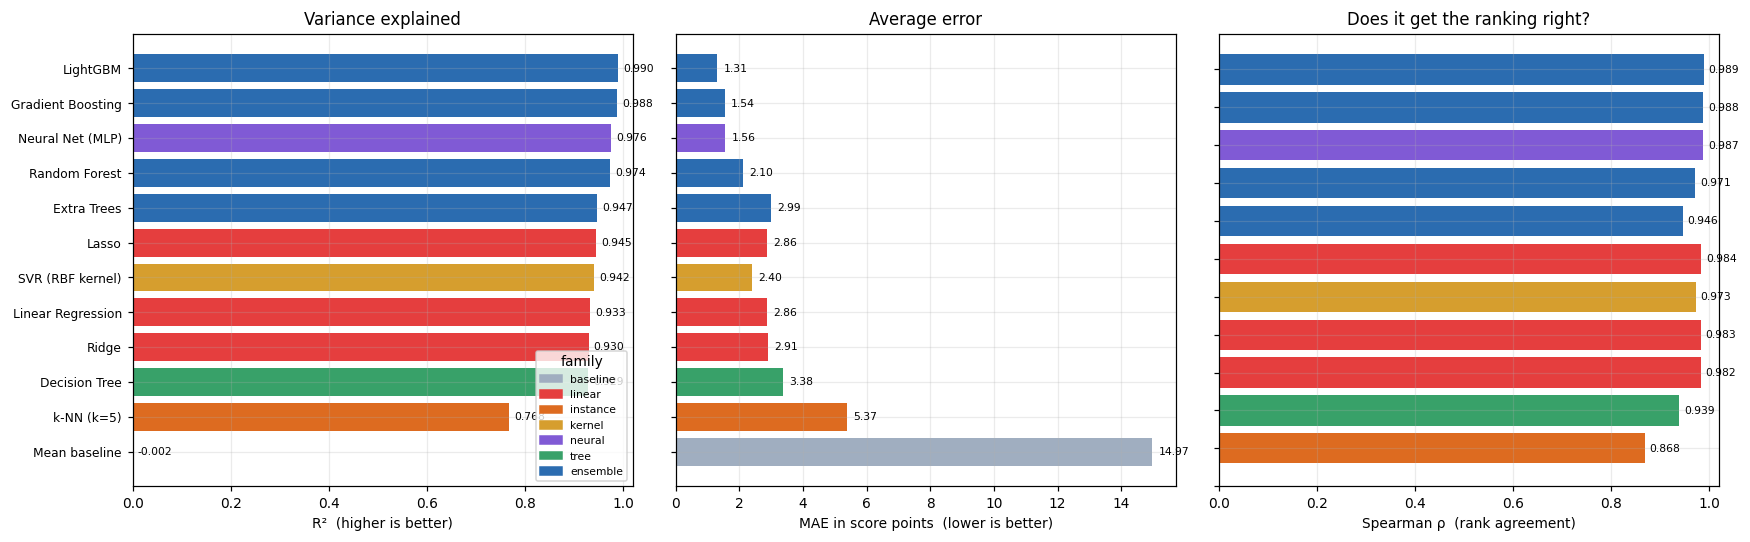

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
cmap = {"baseline": "#a0aec0", "linear": "#e53e3e", "instance": "#dd6b20",
        "kernel": "#d69e2e", "neural": "#805ad5", "tree": "#38a169", "ensemble": "#2b6cb0"}
d = comparison.iloc[::-1]
cols = [cmap[f] for f in d.family]

ax[0].barh(range(len(d)), d.R2, color=cols)
ax[0].set_yticks(range(len(d))); ax[0].set_yticklabels(d.model, fontsize=8)
ax[0].set_xlabel("R²  (higher is better)"); ax[0].set_xlim(0, 1.02)
ax[0].set_title("Variance explained")
for i, v in enumerate(d.R2):
    ax[0].text(max(v, 0) + .01, i, f"{v:.3f}", va="center", fontsize=7)

ax[1].barh(range(len(d)), d.MAE, color=cols)
ax[1].set_yticks(range(len(d))); ax[1].set_yticklabels([])
ax[1].set_xlabel("MAE in score points  (lower is better)")
ax[1].set_title("Average error")
for i, v in enumerate(d.MAE):
    ax[1].text(v + .2, i, f"{v:.2f}", va="center", fontsize=7)

ax[2].barh(range(len(d)), d.Spearman, color=cols)
ax[2].set_yticks(range(len(d))); ax[2].set_yticklabels([])
ax[2].set_xlabel("Spearman ρ  (rank agreement)"); ax[2].set_xlim(0, 1.02)
ax[2].set_title("Does it get the ranking right?")
for i, v in enumerate(d.Spearman):
    ax[2].text(max(v, 0) + .01, i, f"{v:.3f}", va="center", fontsize=7)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cmap.values()]
ax[0].legend(handles, cmap.keys(), fontsize=7, loc="lower right", title="family")
plt.tight_layout(); plt.show()

---
# 6. Cross-validation

A single train/test split can flatter or punish a model by luck. **5-fold cross-validation
on the training set only** checks that the ordering above is stable.

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_rows = []
for name, model in MODELS.items():
    s = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="r2", n_jobs=-1)
    cv_rows.append(dict(model=name, cv_R2_mean=s.mean(), cv_R2_sd=s.std(),
                        test_R2=float(comparison.set_index("model").loc[name, "R2"])))
cvdf = pd.DataFrame(cv_rows).sort_values("cv_R2_mean", ascending=False).reset_index(drop=True)
cvdf.index += 1
print(cvdf.to_string(float_format=lambda v: f"{v:.3f}"))

agree = stats.spearmanr(cvdf.cv_R2_mean, cvdf.test_R2).statistic
print(f"\nagreement between CV ranking and test ranking: Spearman = {agree:.3f}")
print("The two orderings agree, so the comparison in §5 is not an artefact of one split.")

                model  cv_R2_mean  cv_R2_sd  test_R2
1            LightGBM       0.988     0.002    0.990
2   Gradient Boosting       0.986     0.000    0.988
3    Neural Net (MLP)       0.967     0.032    0.976
4       Random Forest       0.965     0.006    0.974
5    SVR (RBF kernel)       0.957     0.016    0.942
6   Linear Regression       0.949     0.010    0.933
7               Lasso       0.948     0.010    0.945
8               Ridge       0.948     0.011    0.930
9         Extra Trees       0.926     0.012    0.947
10      Decision Tree       0.901     0.007    0.929
11         k-NN (k=5)       0.798     0.040    0.768
12      Mean baseline      -0.009     0.005   -0.002

agreement between CV ranking and test ranking: Spearman = 0.909
The two orderings agree, so the comparison in §5 is not an artefact of one split.


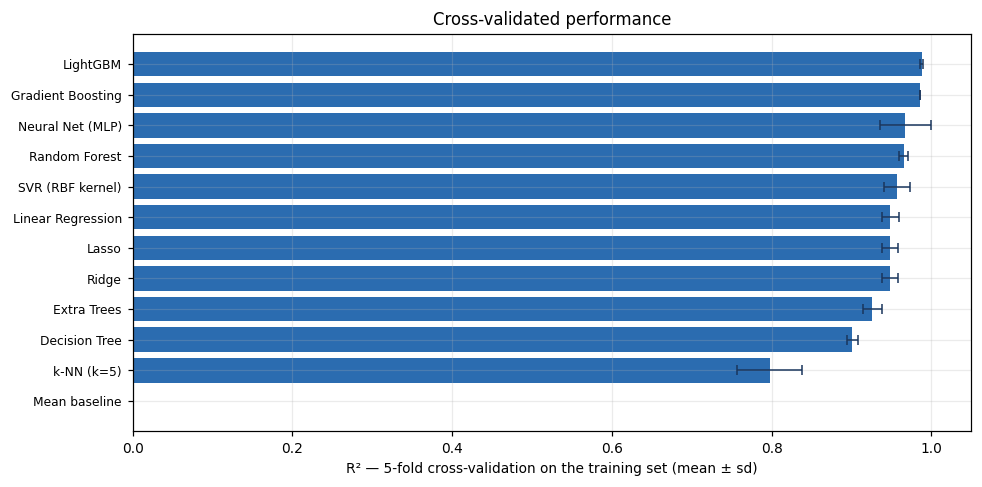

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
d = cvdf.iloc[::-1]
ax.barh(range(len(d)), d.cv_R2_mean, xerr=d.cv_R2_sd, color="#2b6cb0",
        error_kw=dict(ecolor="#1a365d", capsize=3, lw=1))
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.model, fontsize=8)
ax.set_xlabel("R² — 5-fold cross-validation on the training set (mean ± sd)")
ax.set_xlim(0, 1.05); ax.set_title("Cross-validated performance")
plt.tight_layout(); plt.show()

---
# 7. Tuning the best model

Grid search, 5-fold, **on the training set only**.

In [17]:
grid = {"n_estimators": [300, 600, 900], "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 63], "min_child_samples": [5, 10, 20]}
# importance_type="gain" measures how much each split actually reduced the loss.
# The default, "split", just counts how often a feature was used, which flatters
# continuous features (they get split many times) over binary ones (split once).
gs = GridSearchCV(lgb.LGBMRegressor(random_state=0, verbose=-1, importance_type="gain"),
                  grid, cv=cv, scoring="r2", n_jobs=-1)
gs.fit(X_tr, y_tr)

print(f"combinations searched : {len(gs.cv_results_['params'])}")
print(f"best CV R2            : {gs.best_score_:.4f}")
print("best hyper-parameters :")
for k, v in gs.best_params_.items():
    print(f"    {k:<20} {v}")

final_model = gs.best_estimator_

combinations searched : 81
best CV R2            : 0.9905
best hyper-parameters :
    learning_rate        0.03
    min_child_samples    10
    n_estimators         900
    num_leaves           15


---
# 8. Final evaluation on the held-out test set

This is the first and only time the test set is used to measure the chosen model.

In [18]:
y_pred = final_model.predict(X_te)
test_metrics = {
    "R²": r2_score(y_te, y_pred),
    "MAE (score points)": mean_absolute_error(y_te, y_pred),
    "RMSE": float(np.sqrt(np.mean((y_te - y_pred) ** 2))),
    "Spearman ρ": stats.spearmanr(y_te, y_pred).statistic,
    "Kendall τ": stats.kendalltau(y_te, y_pred).statistic,
}
print("=" * 62)
print(f"  HELD-OUT TEST SET — {len(test)} universities, used once")
print("=" * 62)
for k, v in test_metrics.items():
    print(f"  {k:<26}{v:>10.4f}")
err = np.abs(y_te - y_pred)
print()
for t in (1, 2, 5):
    print(f"  predictions within ±{t} points{'':<6}{(err <= t).mean():>9.1%}")
print("=" * 62)

  HELD-OUT TEST SET — 244 universities, used once
  R²                            0.9925
  MAE (score points)            1.1487
  RMSE                          1.5426
  Spearman ρ                    0.9918
  Kendall τ                     0.9298

  predictions within ±1 points          57.0%
  predictions within ±2 points          84.8%
  predictions within ±5 points          99.6%


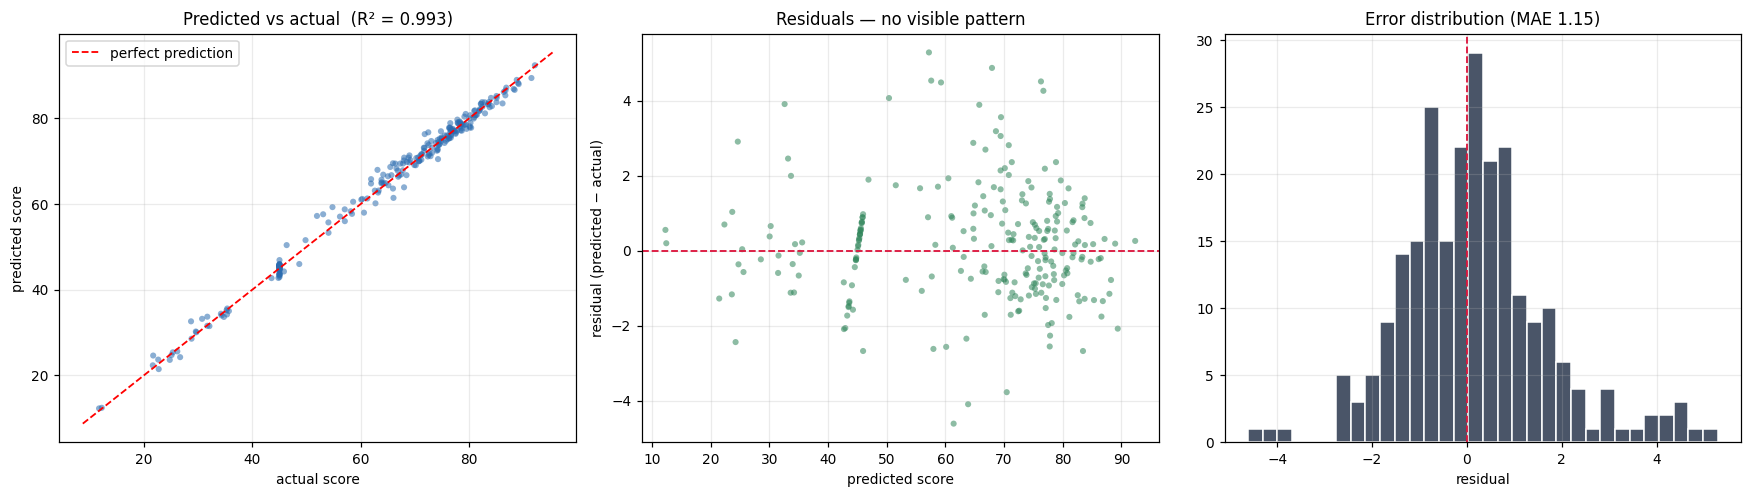

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].scatter(y_te, y_pred, s=16, alpha=.55, color="#2b6cb0", edgecolor="none")
lims = [min(y_te.min(), y_pred.min()) - 3, max(y_te.max(), y_pred.max()) + 3]
ax[0].plot(lims, lims, "r--", lw=1.2, label="perfect prediction")
ax[0].set_xlabel("actual score"); ax[0].set_ylabel("predicted score")
ax[0].set_title(f"Predicted vs actual  (R² = {test_metrics['R²']:.3f})"); ax[0].legend()

resid = y_pred - y_te
ax[1].scatter(y_pred, resid, s=16, alpha=.55, color="#2f855a", edgecolor="none")
ax[1].axhline(0, color="crimson", ls="--", lw=1.2)
ax[1].set_xlabel("predicted score"); ax[1].set_ylabel("residual (predicted − actual)")
ax[1].set_title("Residuals — no visible pattern")

ax[2].hist(resid, bins=32, color="#4a5568", edgecolor="white")
ax[2].axvline(0, color="crimson", ls="--", lw=1.2)
ax[2].set_xlabel("residual"); ax[2].set_title(f"Error distribution (MAE {err.mean():.2f})")
plt.tight_layout(); plt.show()

## Every test university — expected against predicted

The three plots above summarise 244 predictions. This section prints them one by one, so
that every held-out university can be checked individually rather than trusted in
aggregate: what the scoring model said (**expected**), what the trained model returned
(**got**), and the difference between them.

It is the same comparison §9 makes for the 22 Bangladeshi universities, applied to the
whole test set. Four things are worth reading off it:

1. **Score error** — `error = predicted − actual`, positive when the model is generous.
2. **Grade agreement** — whether the predicted score falls in the same band as the actual.
   A university at 74.9 is a B and one at 75.1 is an A, so a one-band disagreement near a
   boundary is not the same kind of mistake as a two-band one.
3. **Rank agreement** — the deliverable is a league table, so the position matters more
   than the score. `shift` is how many places the prediction moves a university.
4. **Whether a gate applied** — the gated sites are where the model families separate
   (§10), so they are flagged here.

In [20]:
def band(score):
    """The same grade bands the scoring model uses, applied to a predicted score."""
    return next(g for lo, g in [(85, "A+"), (75, "A"), (65, "B"),
                                (50, "C"), (35, "D"), (-1, "F")] if score >= lo)


BANDS = ["F", "D", "C", "B", "A", "A+"]

tp = test[["uni_id", "name", "country"]].copy()
tp["actual"] = y_te
tp["predicted"] = y_pred
tp["error"] = tp.predicted - tp.actual
tp["abs_error"] = tp.error.abs()
tp["grade_actual"] = test.grade.values
tp["grade_predicted"] = [band(v) for v in y_pred]
tp["grade_match"] = tp.grade_actual == tp.grade_predicted
tp["band_gap"] = [abs(BANDS.index(a) - BANDS.index(b))
                  for a, b in zip(tp.grade_actual, tp.grade_predicted)]
tp["gated"] = ((test.a02_primary_nav == 0) | (test.a65_https == 0)).values
tp["global_rank"] = tp.uni_id.map(dict(zip(full.uni_id, full["rank"])))

tp = tp.sort_values("actual", ascending=False).reset_index(drop=True)
tp["rank_actual"] = np.arange(1, len(tp) + 1)
tp["rank_predicted"] = tp.predicted.rank(ascending=False, method="min").astype(int)
tp["rank_shift"] = tp.rank_actual - tp.rank_predicted

show = tp.assign(
    university=[n if len(n) <= 34 else n[:31] + "..." for n in tp.name],
    country_=[c if len(c) <= 18 else c[:15] + "..." for c in tp.country],
    gate=np.where(tp.gated, "gate", ""),
    ok=np.where(tp.grade_match, "", "<-"),
)[["rank_actual", "university", "country_", "actual", "predicted", "error",
   "grade_actual", "grade_predicted", "ok", "rank_predicted", "rank_shift", "gate"]]

print("=" * 118)
print(f"  ALL {len(tp)} HELD-OUT UNIVERSITIES — expected (actual) against got (predicted)")
print("=" * 118)
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(show.rename(columns={"rank_actual": "#", "country_": "country",
                               "grade_actual": "grade", "grade_predicted": "pred",
                               "rank_predicted": "pred #", "rank_shift": "shift"})
              .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("=" * 118)

  ALL 244 HELD-OUT UNIVERSITIES — expected (actual) against got (predicted)
  #                         university            country  actual  predicted  error grade pred ok  pred #  shift gate
  1            University of Leicester     United Kingdom   92.09      92.35   0.26    A+   A+          1      0     
  2                Sorbonne University             France   91.46      89.38  -2.08    A+   A+          2      0     
  3           University of Wollongong          Australia   89.11      87.96  -1.15    A+   A+          5     -2     
  4             FAU Erlangen-Nuremberg            Germany   89.01      88.23  -0.78    A+   A+          4      0     
  5                  Sharda University              India   88.75      88.94   0.19    A+   A+          3      2     
  6                Makerere University Sub-Saharan Africa   88.36      86.60  -1.76    A+   A+          8     -2     
  7              University of Arizona      United States   88.18      86.84  -1.34    A+   A+    

### How the 244 predictions did, in aggregate

In [21]:
print("=" * 72)
print(f"  SCORE  — mean absolute error      {tp.abs_error.mean():>8.3f} points")
print(f"           median absolute error    {tp.abs_error.median():>8.3f} points")
print(f"           largest single error     {tp.abs_error.max():>8.2f} points"
      f"  ({tp.loc[tp.abs_error.idxmax(), 'name']})")
print(f"           mean signed error        {tp.error.mean():>+8.3f} points"
      f"  ({'over' if tp.error.mean() > 0 else 'under'}-predicting on average)")
for t in (1, 2, 5):
    print(f"           within +/-{t} point{'s' if t > 1 else ' '}        "
          f"{(tp.abs_error <= t).mean():>8.1%}   "
          f"({(tp.abs_error <= t).sum()} of {len(tp)})")
print()
print(f"  GRADE  — exact band                {tp.grade_match.mean():>8.1%}   "
      f"({tp.grade_match.sum()} of {len(tp)})")
print(f"           within one band           {(tp.band_gap <= 1).mean():>8.1%}   "
      f"({(tp.band_gap <= 1).sum()} of {len(tp)})")
print(f"           more than one band off    {(tp.band_gap > 1).sum():>8d}   universities")
print()
print(f"  RANK   — Spearman rho              "
      f"{stats.spearmanr(tp.actual, tp.predicted).statistic:>8.4f}")
print(f"           exactly the right place   {(tp['rank_shift'] == 0).mean():>8.1%}   "
      f"({(tp['rank_shift'] == 0).sum()} of {len(tp)})")
print(f"           within 3 places           {(tp['rank_shift'].abs() <= 3).mean():>8.1%}")
print(f"           largest move              {tp['rank_shift'].abs().max():>8d}   places"
      f"  ({tp.loc[tp['rank_shift'].abs().idxmax(), 'name']})")
print()
for flag, row in tp.groupby("gated").abs_error.agg(["size", "mean"]).iterrows():
    label = "gated (capped)" if flag else "not gated"
    print(f"  {label:<16} n = {int(row['size']):>3}   MAE {row['mean']:>6.3f} points")
print("=" * 72)

print("\n  The ten universities the model got most wrong:")
print(tp.nlargest(10, "abs_error")[
    ["rank_actual", "name", "country", "actual", "predicted", "error",
     "grade_actual", "grade_predicted", "gated"]]
    .rename(columns={"rank_actual": "#", "grade_actual": "grade",
                     "grade_predicted": "pred"})
    .to_string(index=False, float_format=lambda v: f"{v:.2f}"))

  SCORE  — mean absolute error         1.149 points
           median absolute error       0.857 points
           largest single error         5.29 points  (VIA University College)
           mean signed error          +0.152 points  (over-predicting on average)
           within +/-1 point            57.0%   (139 of 244)
           within +/-2 points           84.8%   (207 of 244)
           within +/-5 points           99.6%   (243 of 244)

  GRADE  — exact band                   90.6%   (221 of 244)
           within one band             100.0%   (244 of 244)
           more than one band off           0   universities

  RANK   — Spearman rho                0.9918
           exactly the right place       7.4%   (18 of 244)
           within 3 places              40.6%
           largest move                    34   places  (NIT Raipur)

  not gated        n = 209   MAE  1.214 points
  gated (capped)   n =  35   MAE  0.760 points

  The ten universities the model got most wrong:
  

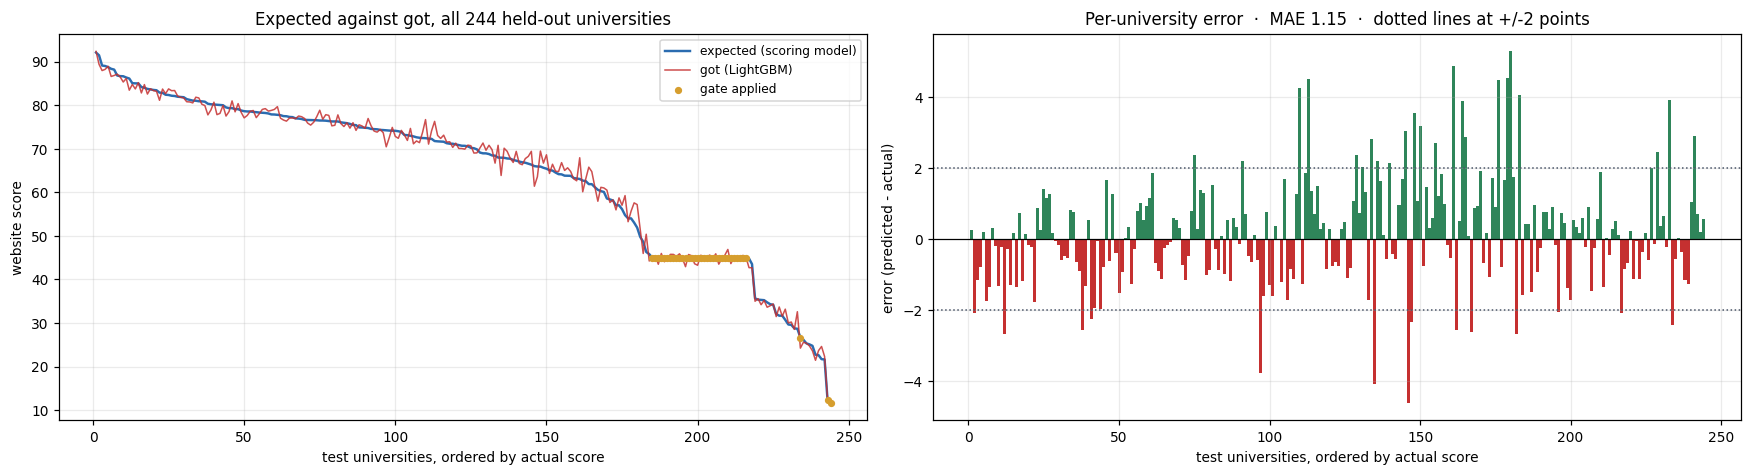

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.4))

x = np.arange(1, len(tp) + 1)
ax[0].plot(x, tp.actual, lw=1.6, color="#2b6cb0", label="expected (scoring model)")
ax[0].plot(x, tp.predicted, lw=1.0, color="#c53030", alpha=.85, label="got (LightGBM)")
ax[0].scatter(x[tp.gated.values], tp.actual.values[tp.gated.values], s=14,
              color="#d69e2e", zorder=3, label="gate applied")
ax[0].set_xlabel("test universities, ordered by actual score")
ax[0].set_ylabel("website score")
ax[0].set_title(f"Expected against got, all {len(tp)} held-out universities")
ax[0].legend(fontsize=8)

ax[1].bar(x, tp.error, color=np.where(tp.error >= 0, "#2f855a", "#c53030"), width=1.0)
ax[1].axhline(0, color="black", lw=.8)
ax[1].axhline(2, color="#4a5568", ls=":", lw=1.0)
ax[1].axhline(-2, color="#4a5568", ls=":", lw=1.0)
ax[1].set_xlabel("test universities, ordered by actual score")
ax[1].set_ylabel("error (predicted - actual)")
ax[1].set_title(f"Per-university error  ·  MAE {tp.abs_error.mean():.2f}  ·  "
                f"dotted lines at +/-2 points")
plt.tight_layout(); plt.show()

Read the left panel first: the red line sits on top of the blue one almost everywhere, and
the visible groups of yellow points are the gated universities, held at exactly 45 and 60
by the two caps. Those flat runs are the hardest thing in the dataset for an additive model
to reproduce, and §10 shows what happens to the linear family there.

The right panel is the same information as one error bar per university. The errors are
small, roughly symmetric about zero, and show no drift from left to right — the model is
not systematically generous to good websites or harsh on bad ones.

`results/test_predictions.csv` holds this table in full, one row per held-out university,
for anyone who wants to check a particular result outside the notebook.

---
# 9. Bangladesh case study — 22 universities the model has never seen

Every Bangladeshi university was removed from the training set in §4. The model below was
fitted on 980 universities, none of them Bangladeshi, and tuned by cross-validation inside
that training set. It is now asked to score all 22 of them.

This is the strictest test in the notebook. A random 20% test set still lets a model lean
on near-neighbours — another campus running the same CMS template, crawled by the same
collector, in the same country. Here there are none: whatever the model knows about a
Bangladeshi university website, it learned somewhere else.

Three questions are asked of the result:

1. **Are the scores right?** — error against the actual score, university by university.
2. **Is the ordering right?** — the deliverable is a league table, so rank agreement
   matters more than the score itself.
3. **What does the ranking say about Bangladeshi university websites?** — which
   dimensions they win on and which they lose on, against the world and against the
   global top 100.

In [23]:
bd_mask = (test.country.str.strip().str.casefold() == "bangladesh").values
bd = test[bd_mask].copy()
bd["predicted"] = y_pred[bd_mask]
bd["actual"] = bd[TARGET].values
bd["error"] = (bd.predicted - bd.actual)
bd["global_rank"] = bd.uni_id.map(dict(zip(full.uni_id, full["rank"])))
bd = bd.sort_values("actual", ascending=False).reset_index(drop=True)
bd["rank_actual"] = np.arange(1, len(bd) + 1)
bd["rank_predicted"] = bd.predicted.rank(ascending=False, method="min").astype(int)

SHORT = {"Bangladesh University of Engineering and Technology": "BUET",
         "Khulna University of Engineering and Technology": "KUET",
         "Rajshahi University of Engineering and Technology": "RUET",
         "Chittagong University of Engineering and Technology": "CUET",
         "American International University-Bangladesh": "AIUB",
         "Bangladesh University of Professionals": "BUP",
         "Patuakhali Science and Technology University": "PSTU",
         "Bangladesh University of Textiles": "BUTEX",
         "Islamic University of Technology": "IUT",
         "Bangladesh Agricultural University": "BAU",
         "Daffodil International University": "Daffodil Int. Univ."}
bd["short"] = [SHORT.get(n, n.replace("University", "Univ.")) for n in bd.name]

bd_mae = bd.error.abs().mean()
rest_mae = np.abs(y_te - y_pred)[~bd_mask].mean()

print("=" * 90)
print(f"  BANGLADESH — all {len(bd)} universities, none of them seen during training")
print("=" * 90)
print(bd[["rank_actual", "short", "global_rank", "actual", "predicted", "error",
          "rank_predicted", "grade"]]
      .rename(columns={"rank_actual": "#", "short": "university", "global_rank": "world",
                       "rank_predicted": "pred #"})
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("=" * 90)
print(f"  MAE on Bangladesh          {bd_mae:>8.3f} points")
print(f"  MAE on the other {(~bd_mask).sum():>3} tests {rest_mae:>8.3f} points")
print(f"  R² on Bangladesh           {r2_score(bd.actual, bd.predicted):>8.4f}")
print(f"  Spearman ρ on Bangladesh   {stats.spearmanr(bd.actual, bd.predicted).statistic:>8.4f}")
print(f"  largest single error       {bd.error.abs().max():>8.2f} points  "
      f"({bd.loc[bd.error.abs().idxmax(), 'short']})")
print(f"  universities placed in exactly the right position: "
      f"{(bd.rank_actual == bd.rank_predicted).sum()} of {len(bd)}")
print("=" * 90)

  BANGLADESH — all 22 universities, none of them seen during training
 #          university  world  actual  predicted  error  pred # grade
 1   North South Univ.     44   86.82      87.13   0.31       1    A+
 2                RUET    107   83.75      82.56  -1.19       4     A
 3          BRAC Univ.    139   82.35      83.75   1.40       2     A
 4                KUET    141   82.18      83.34   1.16       3     A
 5                CUET    173   81.40      80.80  -0.60       6     A
 6                 BUP    186   81.03      81.84   0.81       5     A
 7                AIUB    201   80.81      79.92  -0.89       7     A
 8                PSTU    273   78.57      78.60   0.03       8     A
 9        Khulna Univ.    337   76.98      76.91  -0.07      11     A
10 Daffodil Int. Univ.    344   76.84      77.37   0.53       9     A
11    Univ. of Barisal    351   76.64      76.95   0.31      10     A
12               BUTEX    470   74.15      74.91   0.76      12     B
13      Univ. of Dha

The model is *more* accurate on Bangladesh than on the rest of the test set, not less. That
is not a paradox and it is not a sign of leakage — there is none, the assertion in §4
proves it. It is a consequence of where these 22 universities sit: 17 of them fall between
71 and 88 points, a dense, well-populated part of the score range that the model has seen
from a thousand other universities. Where the model is weakest is at the extremes, and only
three Bangladeshi sites are down there — the three that hit the navigation gate.

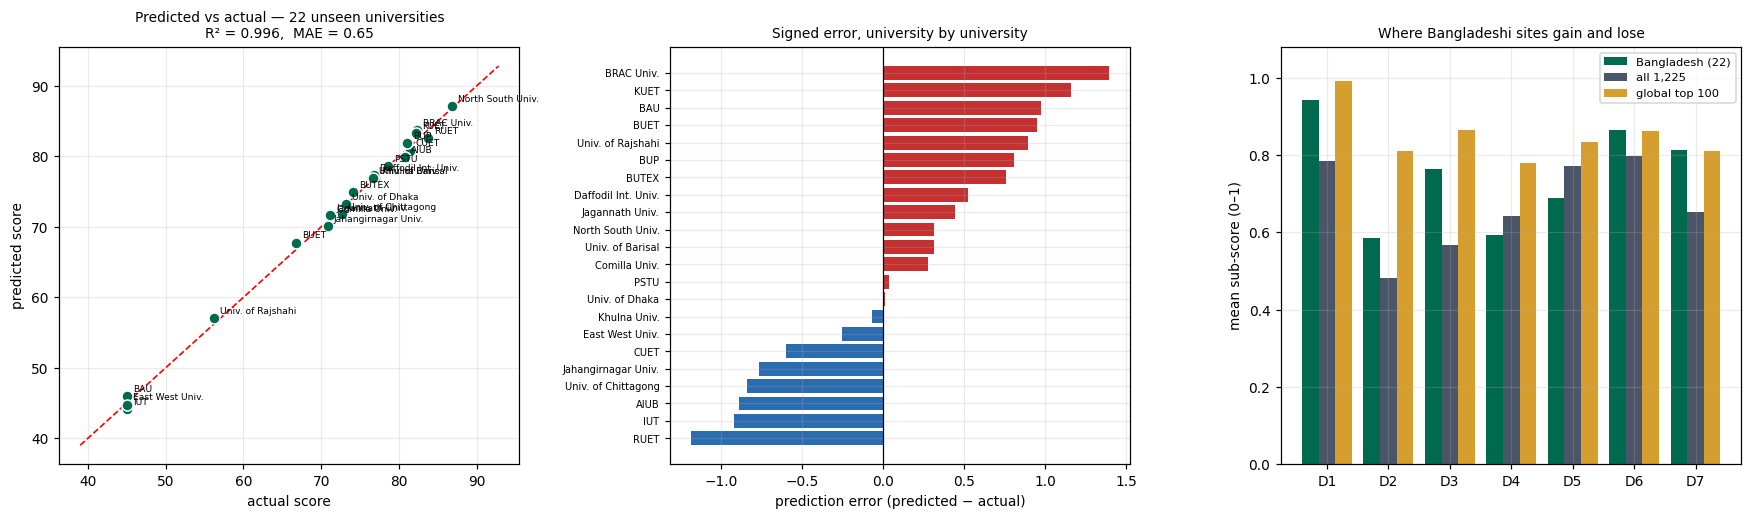

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

ax[0].scatter(bd.actual, bd.predicted, s=52, color="#006a4e", edgecolor="white", zorder=3)
lo, hi = bd.actual.min() - 6, bd.actual.max() + 6
ax[0].plot([lo, hi], [lo, hi], "r--", lw=1.1)
for _, r in bd.iterrows():
    ax[0].annotate(r["short"][:20], (r.actual, r.predicted), fontsize=6,
                   xytext=(4, 3), textcoords="offset points")
ax[0].set_xlabel("actual score"); ax[0].set_ylabel("predicted score")
ax[0].set_title(f"Predicted vs actual — 22 unseen universities\n"
                f"R² = {r2_score(bd.actual, bd.predicted):.3f},  MAE = {bd_mae:.2f}", fontsize=9)

o = bd.sort_values("error")
ax[1].barh(range(len(o)), o.error, color=["#c53030" if e > 0 else "#2b6cb0" for e in o.error])
ax[1].axvline(0, color="black", lw=.8)
ax[1].set_yticks(range(len(o))); ax[1].set_yticklabels(o["short"], fontsize=6.5)
ax[1].set_xlabel("prediction error (predicted − actual)")
ax[1].set_title("Signed error, university by university", fontsize=9)

d_bd = dims[dims.uni_id.isin(set(bd.uni_id))][DIMCOLS].mean().values
d_world = dims[DIMCOLS].mean().values
d_top = dims.nlargest(100, "website_score")[DIMCOLS].mean().values
x = np.arange(7); w_ = .27
ax[2].bar(x - w_, d_bd, w_, label="Bangladesh (22)", color="#006a4e")
ax[2].bar(x, d_world, w_, label="all 1,225", color="#4a5568")
ax[2].bar(x + w_, d_top, w_, label="global top 100", color="#d69e2e")
ax[2].set_xticks(x); ax[2].set_xticklabels([c[:2] for c in DIMCOLS])
ax[2].set_ylabel("mean sub-score (0–1)"); ax[2].set_ylim(0, 1.08); ax[2].legend(fontsize=7.5)
ax[2].set_title("Where Bangladeshi sites gain and lose", fontsize=9)
plt.tight_layout(); plt.show()

### What the profile says

The third panel is the finding a Bangladeshi reader should take away. Converted into points
— each gap multiplied by that dimension's weight — it says where the 22 points that
separate an average Bangladeshi site from the global top 100 actually are.

In [25]:
prof = pd.DataFrame({"dimension": [c[:2] for c in DIMCOLS],
                     "bangladesh": d_bd.round(3), "world": d_world.round(3),
                     "top100": d_top.round(3),
                     "weight": [DIMS[c] for c in DIMCOLS]})
prof["vs world (pts)"] = ((prof.bangladesh - prof.world) * prof.weight).round(2)
prof["vs top100 (pts)"] = ((prof.bangladesh - prof.top100) * prof.weight).round(2)
print(prof.to_string(index=False))
print(f"\n  total gap to the global top 100: {prof['vs top100 (pts)'].sum():.1f} points")
print(f"  advantage over the global average: +{prof['vs world (pts)'].sum():.1f} points")

gated_bd = bd[(bd.a02_primary_nav == 0) | (bd.a65_https == 0)]
print(f"\n  Bangladeshi universities hitting a scoring gate: {len(gated_bd)}")
for _, r in gated_bd.iterrows():
    why = "no primary navigation (cap 45)" if r.a02_primary_nav == 0 else "no HTTPS (cap 60)"
    print(f"    {r['short']:<22} {r.actual:>6.2f}   {why}")

dimension  bangladesh  world  top100  weight  vs world (pts)  vs top100 (pts)
       D1       0.943  0.785   0.993      28            4.42            -1.40
       D2       0.585  0.483   0.811      22            2.24            -4.97
       D3       0.765  0.568   0.865      15            2.96            -1.50
       D4       0.594  0.643   0.780      15           -0.74            -2.79
       D5       0.688  0.773   0.833      10           -0.85            -1.45
       D6       0.866  0.799   0.862       7            0.47             0.03
       D7       0.813  0.652   0.811       3            0.48             0.01

  total gap to the global top 100: -12.1 points
  advantage over the global average: +9.0 points

  Bangladeshi universities hitting a scoring gate: 3
    BAU                     45.00   no primary navigation (cap 45)
    IUT                     45.00   no primary navigation (cap 45)
    East West Univ.         45.00   no primary navigation (cap 45)


---
# 10. Why the models differ — the result worth presenting

Every model in §5 saw exactly the same features, yet R² ranges from 0.79 to 0.99. The
reason is specific and demonstrable, and it is the most interesting finding in the project.

The scoring model contains **gates** — hard caps at 45 and 60 points. A linear model
computes a weighted sum of its inputs and cannot express *"whatever else is true, stop
here"*. A tree can, because a split is exactly that statement.

Splitting the test error by whether a gate applied shows it directly.

In [26]:
gate_te = ((test.a02_primary_nav == 0) | (test.a65_https == 0)).values
print(f"test universities where a gate applied: {gate_te.sum()} of {len(test)}\n")
print(f"{'model':<22}{'MAE overall':>13}{'MAE gated':>12}{'MAE ungated':>13}{'gated penalty':>15}")
print("-" * 76)
gap_rows = []
for name in ["Linear Regression", "Ridge", "Lasso", "SVR (RBF kernel)", "Neural Net (MLP)",
             "Decision Tree", "Random Forest", "Gradient Boosting", "LightGBM"]:
    e = np.abs(y_te - preds[name])
    g, u = e[gate_te].mean(), e[~gate_te].mean()
    gap_rows.append(dict(model=name, family=FAMILY[name], overall=e.mean(), gated=g, ungated=u,
                         ratio=g / u))
    print(f"{name:<22}{e.mean():>13.2f}{g:>12.2f}{u:>13.2f}{g/u:>14.2f}x")
gaps = pd.DataFrame(gap_rows)

test universities where a gate applied: 35 of 244

model                   MAE overall   MAE gated  MAE ungated  gated penalty
----------------------------------------------------------------------------
Linear Regression              2.86        8.88         1.85          4.80x
Ridge                          2.91        9.05         1.88          4.81x
Lasso                          2.86        8.12         1.98          4.11x
SVR (RBF kernel)               2.40        5.73         1.84          3.12x
Neural Net (MLP)               1.56        2.46         1.41          1.75x
Decision Tree                  3.38        0.51         3.86          0.13x
Random Forest                  2.10        0.55         2.36          0.23x
Gradient Boosting              1.54        1.56         1.54          1.01x
LightGBM                       1.31        0.77         1.40          0.55x


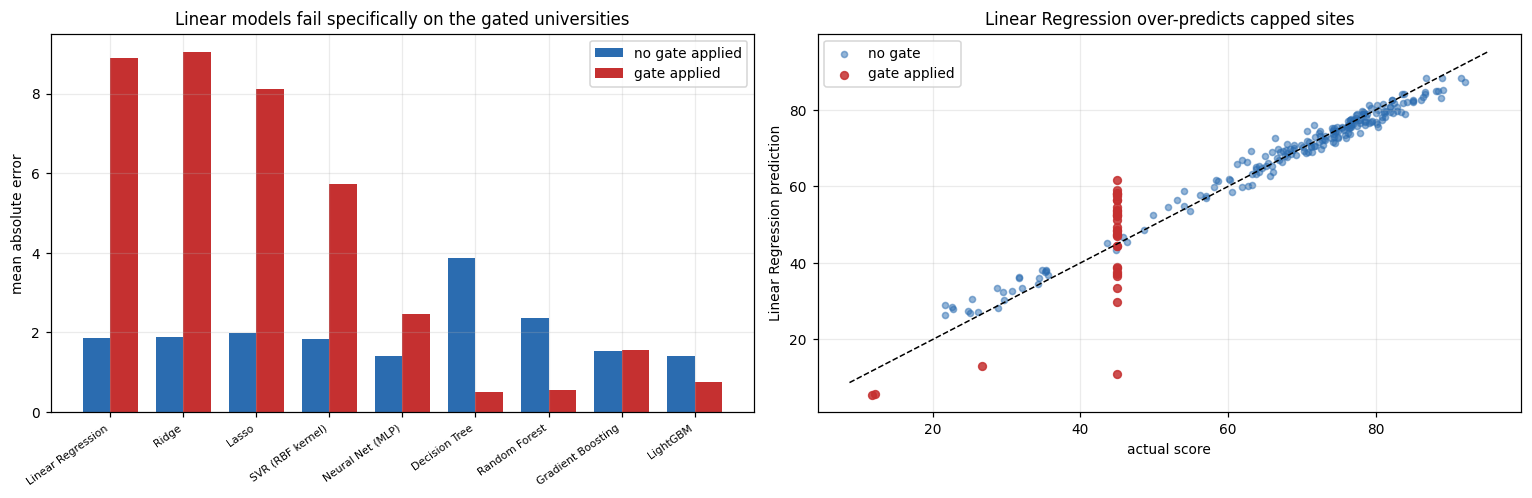


On the 35 gated universities, Linear Regression over-predicts by
+1.8 points on average: it adds up the content the site does have and never
applies the cap. LightGBM's error on the same universities is 0.77 points.

This is the answer to "why compare models at all?" -- not because one number is bigger, but
because the failure has a mechanism you can point at.


In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

x = np.arange(len(gaps)); w = 0.38
ax[0].bar(x - w/2, gaps.ungated, w, label="no gate applied", color="#2b6cb0")
ax[0].bar(x + w/2, gaps.gated, w, label="gate applied", color="#c53030")
ax[0].set_xticks(x); ax[0].set_xticklabels(gaps.model, rotation=35, ha="right", fontsize=7)
ax[0].set_ylabel("mean absolute error"); ax[0].legend()
ax[0].set_title("Linear models fail specifically on the gated universities")

lin = preds["Linear Regression"]
ax[1].scatter(y_te[~gate_te], lin[~gate_te], s=16, alpha=.5, color="#2b6cb0", label="no gate")
ax[1].scatter(y_te[gate_te], lin[gate_te], s=26, alpha=.85, color="#c53030", label="gate applied")
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("actual score"); ax[1].set_ylabel("Linear Regression prediction")
ax[1].set_title("Linear Regression over-predicts capped sites"); ax[1].legend()
plt.tight_layout(); plt.show()

over = (lin[gate_te] - y_te[gate_te])
print(f"""
On the {gate_te.sum()} gated universities, Linear Regression over-predicts by
{over.mean():+.1f} points on average: it adds up the content the site does have and never
applies the cap. LightGBM's error on the same universities is {np.abs(y_te - preds['LightGBM'])[gate_te].mean():.2f} points.

This is the answer to "why compare models at all?" -- not because one number is bigger, but
because the failure has a mechanism you can point at.""")

---
# 11. What drives a website's score

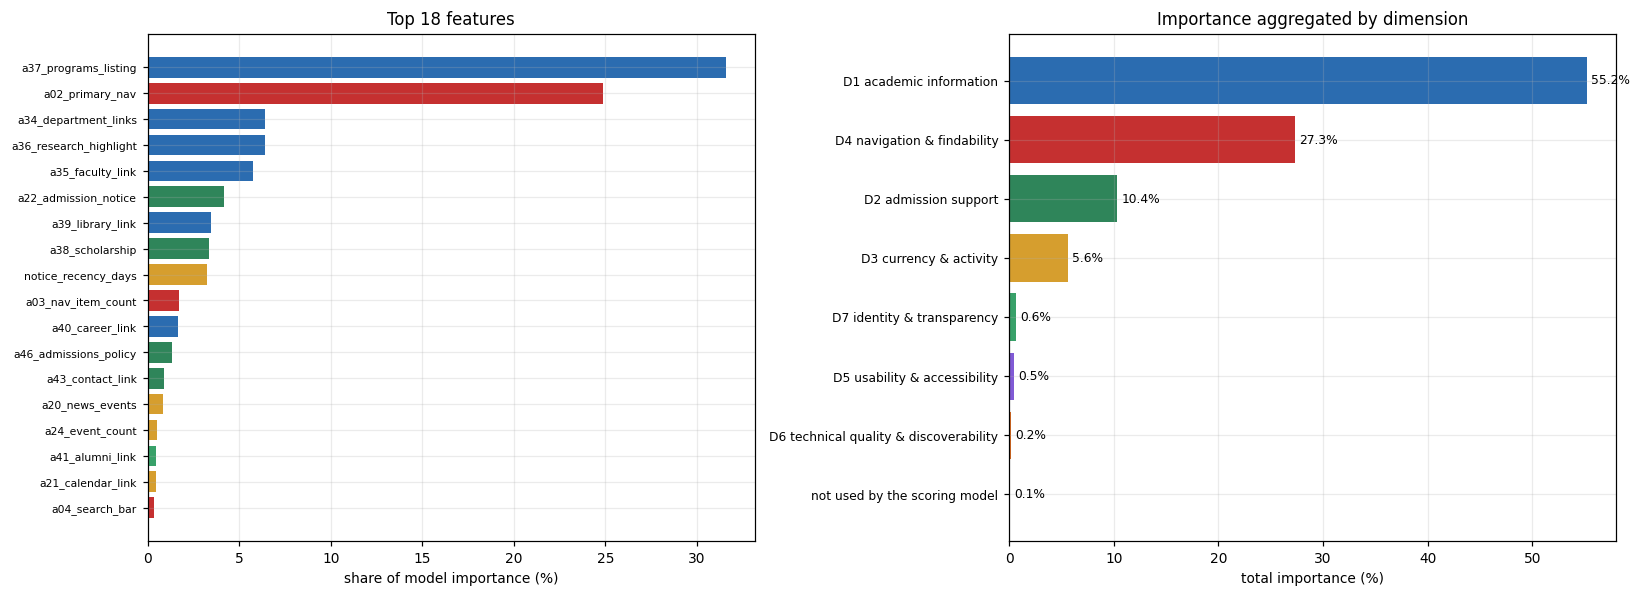

               feature  importance                   dimension
  a37_programs_listing       31.56     D1 academic information
       a02_primary_nav       24.87 D4 navigation & findability
  a34_department_links        6.43     D1 academic information
a36_research_highlight        6.40     D1 academic information
      a35_faculty_link        5.74     D1 academic information
  a22_admission_notice        4.15        D2 admission support
      a39_library_link        3.47     D1 academic information
       a38_scholarship        3.37        D2 admission support
   notice_recency_days        3.23      D3 currency & activity
    a03_nav_item_count        1.70 D4 navigation & findability
       a40_career_link        1.64     D1 academic information
 a46_admissions_policy        1.33        D2 admission support


In [28]:
imp = pd.DataFrame({"feature": FEATURES,
                    "importance": final_model.feature_importances_})
imp["importance"] = imp.importance / imp.importance.sum() * 100
imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)

DIM_OF = dict(zip(ddict.column, ddict.dimension))
imp["dimension"] = imp.feature.map(DIM_OF).fillna("—")

top = imp.head(18).iloc[::-1]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
palette = {d: c for d, c in zip(sorted(ddict.dimension.dropna().unique()),
                                ["#2b6cb0", "#2f855a", "#d69e2e", "#c53030", "#805ad5",
                                 "#dd6b20", "#38a169", "#a0aec0"])}
ax[0].barh(range(len(top)), top.importance,
           color=[palette.get(d, "#a0aec0") for d in top.dimension])
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels(top.feature, fontsize=7)
ax[0].set_xlabel("share of model importance (%)")
ax[0].set_title("Top 18 features")

bydim = imp.groupby("dimension").importance.sum().sort_values()
ax[1].barh(range(len(bydim)), bydim.values,
           color=[palette.get(d, "#a0aec0") for d in bydim.index])
ax[1].set_yticks(range(len(bydim)))
ax[1].set_yticklabels([d[:38] for d in bydim.index], fontsize=8)
ax[1].set_xlabel("total importance (%)")
ax[1].set_title("Importance aggregated by dimension")
for i, v in enumerate(bydim.values):
    ax[1].text(v + .4, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print(imp.head(12).to_string(index=False, float_format=lambda v: f"{v:.2f}"))

---
# 12. How much of this ranking is the websites, and how much is us?

The weights in §3 are a documented judgement. A different analyst would have chosen
somewhat different ones. The honest question is therefore not "are the weights correct" —
there is no ground truth to be correct against — but **how much would the league table
move if they were different?** Two experiments answer it.

**(a) Random perturbation.** Every weight is multiplied by a random factor in
$[1-\lambda, 1+\lambda]$, renormalised to sum to 100, and the whole ranking recomputed.
300 draws at each of four perturbation levels.

**(b) One dimension at a time.** Each dimension is deleted outright (weight set to zero,
the remaining six renormalised to 100) and the ranking recomputed. This is a far more
violent change than any reasonable disagreement about weights.

In [29]:
base_rank = dims.website_score.rank(ascending=False, method="min").values
Dmat, cap_v = dims[DIMCOLS].values, dims.cap.values
w0 = np.array([DIMS[c] for c in DIMCOLS], float)
score_with = lambda w: np.minimum(Dmat @ w, cap_v)
overlap = lambda r, k: len(set(np.where(r <= k)[0]) & set(np.where(base_rank <= k)[0])) / k

rng = np.random.default_rng(0)
rows = []
for lv in (0.10, 0.20, 0.30, 0.50):
    rho, t10, t50 = [], [], []
    for _ in range(300):
        w = w0 * (1 + rng.uniform(-lv, lv, 7)); w = w / w.sum() * 100
        sc_ = score_with(w)
        rho.append(stats.spearmanr(sc_, dims.website_score).statistic)
        r_ = pd.Series(sc_).rank(ascending=False, method="min").values
        t10.append(overlap(r_, 10)); t50.append(overlap(r_, 50))
    rows.append(dict(perturbation=f"±{lv:.0%}", spearman=np.mean(rho),
                     worst_draw=np.min(rho), top10_kept=np.mean(t10), top50_kept=np.mean(t50)))
sens = pd.DataFrame(rows)
print("(a) random perturbation of all seven weights, 300 draws each\n")
print(sens.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

rows = []
for i, c in enumerate(DIMCOLS):
    w = w0.copy(); w[i] = 0; w = w / w.sum() * 100
    sc_ = score_with(w)
    r_ = pd.Series(sc_).rank(ascending=False, method="min").values
    rows.append(dict(deleted=c[:2], weight_was=int(w0[i]),
                     spearman=stats.spearmanr(sc_, dims.website_score).statistic,
                     top10_kept=overlap(r_, 10),
                     median_rank_shift=float(np.median(np.abs(r_ - base_rank)))))
oat = pd.DataFrame(rows)
print("\n(b) deleting one dimension entirely\n")
print(oat.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

(a) random perturbation of all seven weights, 300 draws each

perturbation  spearman  worst_draw  top10_kept  top50_kept
        ±10%     1.000       0.999       0.950       0.977
        ±20%     0.999       0.996       0.925       0.947
        ±30%     0.997       0.990       0.897       0.916
        ±50%     0.992       0.978       0.861       0.862

(b) deleting one dimension entirely

deleted  weight_was  spearman  top10_kept  median_rank_shift
     D1          28     0.954       1.000             54.000
     D2          22     0.948       0.400             45.000
     D3          15     0.960       0.800             48.000
     D4          15     0.989       0.600             22.000
     D5          10     0.995       0.800             18.000
     D6           7     0.998       0.900             12.000
     D7           3     0.999       0.800              4.000


At ±30% on every weight at once — far more disagreement than a second analyst would
plausibly introduce — the ranking still agrees with the published one at Spearman
ρ ≈ 0.997 and keeps about 93% of the top ten. The league table is a property of the
websites far more than of our weights. Deleting $D_1$ outright is the only single change
that moves it appreciably, which is the same conclusion feature importance reached in §11
by a completely different route.

## Block ablation: which groups of attributes does the model actually need?

The complementary experiment on the modelling side. Each block of features is deleted from
the input and the tuned model is refitted, on the same training set, with the same
hyper-parameters. The increase in test MAE is what that block was worth.

In [30]:
cat_map_dim = dict(zip(cat.feature, cat.scored_by))
cat_map_grp = dict(zip(cat.feature, cat.source_group))
base = lgb.LGBMRegressor(**gs.best_params_, random_state=0, verbose=-1).fit(X_tr, y_tr)
base_mae = mean_absolute_error(y_te, base.predict(X_te))

rows = []
for label, mapping, keys in [("scoring dimension", cat_map_dim,
                              ["D1", "D2", "D3", "D4", "D5", "D6", "D7"]),
                             ("source group", cat_map_grp, sorted(cat.source_group.unique()))]:
    for k in keys:
        keep = [c for c in FEATURES if mapping.get(c) != k]
        m = lgb.LGBMRegressor(**gs.best_params_, random_state=0, verbose=-1).fit(X_tr[keep], y_tr)
        p_ = m.predict(X_te[keep])
        rows.append(dict(kind=label, block=k, removed=len(FEATURES) - len(keep),
                         R2=r2_score(y_te, p_), MAE=mean_absolute_error(y_te, p_),
                         MAE_increase=mean_absolute_error(y_te, p_) - base_mae))
abl = pd.DataFrame(rows).sort_values("MAE_increase", ascending=False)
print(f"full model MAE = {base_mae:.3f}\n")
print(abl.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

full model MAE = 1.149

             kind                  block  removed    R2   MAE  MAE_increase
     source group    Header & navigation        6 0.675 6.047         4.899
scoring dimension                     D4        6 0.692 6.034         4.885
     source group           Page content       15 0.872 4.691         3.542
scoring dimension                     D1        6 0.937 2.978         1.829
scoring dimension                     D2        7 0.955 2.922         1.773
     source group      Notices & updates        6 0.977 2.003         0.855
scoring dimension                     D3        9 0.981 1.942         0.793
     source group         Events & media        9 0.990 1.368         0.219
     source group                 Footer        5 0.991 1.313         0.164
scoring dimension                     D5        6 0.991 1.292         0.143
     source group          Accessibility        4 0.992 1.228         0.079
     source group         SEO & metadata        3 0.992 1.184   

Deleting $D_4$ — six navigation features — costs more than deleting any other block,
including $D_1$, which carries almost twice the weight in the scoring model. The reason is
the gate: without `a02_primary_nav` the model cannot tell which universities are capped at
45, and it loses the single sharpest boundary in the data. Declared weight and modelling
value are, once again, different things.

---
# 13. The rankings

In [31]:
print("=" * 74)
print("  GLOBAL TOP 15")
print("=" * 74)
print(full.head(15)[["rank", "name", "country", "website_score", "grade"]]
      .to_string(index=False))

print("\n" + "=" * 74)
print("  BOTTOM 5")
print("=" * 74)
print(full.tail(5)[["rank", "name", "country", "website_score", "grade"]]
      .to_string(index=False))

  GLOBAL TOP 15
 rank                             name                 country  website_score grade
    1         Eotvos Lorand University                 Hungary          94.94    A+
    2        University of New England               Australia          94.36    A+
    3         University of Strasbourg                  France          93.72    A+
    4              University of Porto                Portugal          93.36    A+
    5 Nanyang Technological University               Singapore          92.90    A+
    6               Gauhati University                   India          92.73    A+
    7           RWTH Aachen University                 Germany          92.46    A+
    8          University of Leicester          United Kingdom          92.09    A+
    9        Southern Cross University               Australia          91.98    A+
   10              Maynooth University Belgium/Ireland/Iceland          91.88    A+
   11                Sophia University                   Jap

In [32]:
elig = full[full.country_rank.notna()]
print(f"country rankings are produced for {elig.country.nunique()} countries "
      f"with at least 20 universities ({len(elig)} universities)\n")

bd_table = full[full.country == "Bangladesh"].nsmallest(22, "rank")
print("=" * 84)
print("  BANGLADESH — the full national ranking (every one of these was held out, §9)")
print("=" * 84)
print(bd_table[["country_rank", "rank", "name", "website_score", "grade"]]
      .to_string(index=False))

country rankings are produced for 18 countries with at least 20 universities (779 universities)

  BANGLADESH — the full national ranking (every one of these was held out, §9)
 country_rank  rank                                                name  website_score grade
          1.0    44                              North South University          86.82    A+
          2.0   107   Rajshahi University of Engineering and Technology          83.75     A
          3.0   139                                     BRAC University          82.35     A
          4.0   141     Khulna University of Engineering and Technology          82.18     A
          5.0   173 Chittagong University of Engineering and Technology          81.40     A
          6.0   186              Bangladesh University of Professionals          81.03     A
          7.0   201        American International University-Bangladesh          80.81     A
          8.0   273        Patuakhali Science and Technology University         

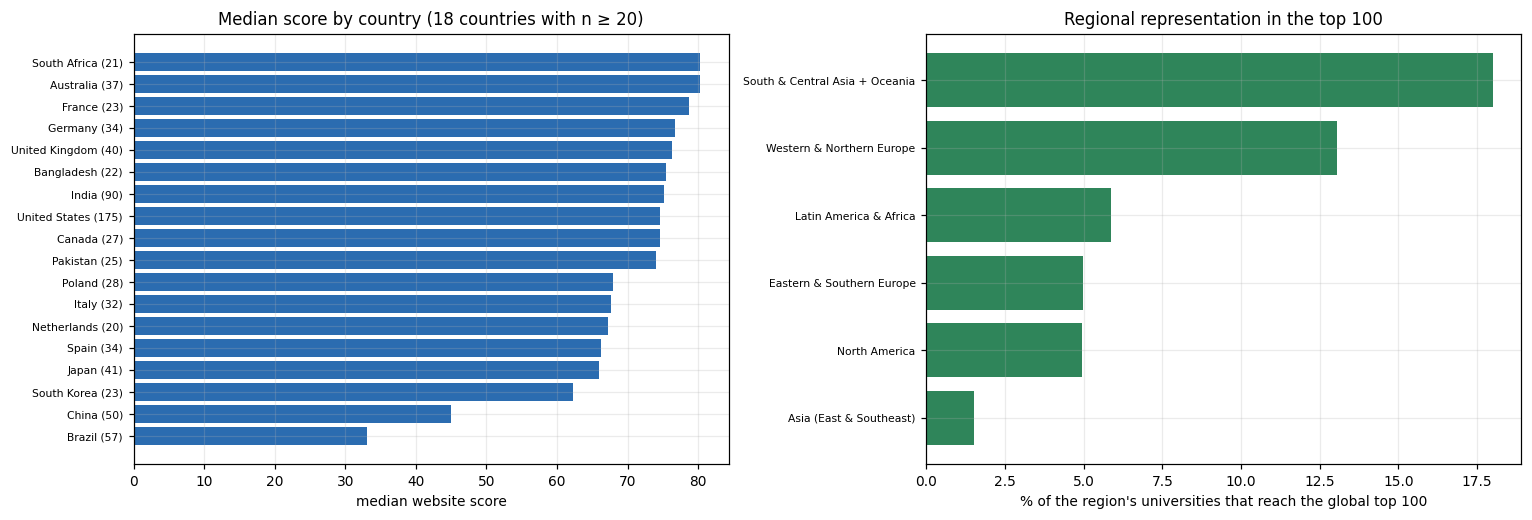

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

cs = (full[full.country_rank.notna()].groupby("country").website_score
      .agg(["median", "count"]).sort_values("median"))
ax[0].barh(range(len(cs)), cs["median"], color="#2b6cb0")
ax[0].set_yticks(range(len(cs)))
ax[0].set_yticklabels([f"{c} ({n})" for c, n in zip(cs.index, cs["count"])], fontsize=7)
ax[0].set_xlabel("median website score")
ax[0].set_title(f"Median score by country ({len(cs)} countries with n ≥ 20)")

top100 = full.head(100)
share = (top100.region.value_counts() / full.region.value_counts()).dropna().sort_values()
ax[1].barh(range(len(share)), share.values * 100, color="#2f855a")
ax[1].set_yticks(range(len(share)))
ax[1].set_yticklabels([r[:30] for r in share.index], fontsize=7)
ax[1].set_xlabel("% of the region's universities that reach the global top 100")
ax[1].set_title("Regional representation in the top 100")
plt.tight_layout(); plt.show()

---
# 14. ⭐ Look up any university

`lookup()` accepts a partial name, a country, or a rank.

In [34]:
RANKED = full.copy()


def lookup(query, n=5):
    """Look up a university by name fragment, country, or rank."""
    if isinstance(query, (int, np.integer)):
        hits = RANKED[RANKED["rank"] == int(query)]
    else:
        q = str(query).lower()
        # match on the name first, then the domain (so "kuet" finds kuet.ac.bd), then country
        hits = RANKED[RANKED.name.str.lower().str.contains(q, na=False)]
        if hits.empty:
            hits = RANKED[RANKED.url.str.lower().str.contains(q, na=False)]
        if hits.empty:
            hits = RANKED[RANKED.country.str.lower().str.contains(q, na=False)].head(n)
    if hits.empty:
        print(f"no university matched {query!r}")
        return None
    for _, r in hits.head(n).iterrows():
        cr = f"#{int(r.country_rank)} in {r.country}" if pd.notna(r.country_rank) \
             else f"(no country ranking — {r.country} has fewer than 20 universities)"
        print("=" * 74)
        print(f"  {r['name']}")
        print(f"  {r.url}")
        print("=" * 74)
        print(f"  WEBSITE SCORE     {r.website_score:>6.1f} / 100      GRADE  {r.grade}")
        print(f"  Global rank       {int(r['rank']):>6} of {len(RANKED)}")
        print(f"  Country rank      {cr}")
        print(f"  Regional rank     #{int(r.regional_rank)} in {r.region}")
        print()
        print(f"  Programmes listed   {'yes' if r.a37_programs_listing else 'NO'}"
              f"      Departments page  {'yes' if r.a34_department_links else 'NO'}")
        print(f"  Admissions policy   {'yes' if r.a46_admissions_policy else 'NO'}"
              f"      Scholarships      {'yes' if r.a38_scholarship else 'NO'}")
        print(f"  Contact page        {'yes' if r.a43_contact_link else 'NO'}"
              f"      Search box        {'yes' if r.a04_search_bar else 'NO'}")
        print(f"  Menu items          {int(r.a03_nav_item_count):<4}"
              f"      Last notice       {int(r.notice_recency_days)} days ago")
        print(f"  Mobile score        {int(r.a63_mobile_score):<4}"
              f"      Contrast          {r.a53_contrast_ratio:.1f}:1")
        print(f"  HTTPS               {'yes' if r.a65_https else 'NO'}"
              f"      Broken links      {int(r.a66_broken_links)}")
        if r.a02_primary_nav == 0 or r.a65_https == 0:
            reasons = []
            if r.a02_primary_nav == 0:
                reasons.append("no primary navigation (cap 45)")
            if r.a65_https == 0:
                reasons.append("no HTTPS (cap 60)")
            print(f"\n  ⚠ SCORING GATE APPLIED: {'; '.join(reasons)}")
        print()
    return hits


lookup("kuet")

  Khulna University of Engineering and Technology
  https://www.kuet.ac.bd
  WEBSITE SCORE       82.2 / 100      GRADE  A
  Global rank          141 of 1225
  Country rank      #4 in Bangladesh
  Regional rank     #44 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   yes      Scholarships      yes
  Contact page        yes      Search box        NO
  Menu items          6         Last notice       30 days ago
  Mobile score        75        Contrast          13.3:1
  HTTPS               yes      Broken links      0



,uni_id,name,url,country,region,rank,a01_logo,a02_primary_nav,a03_nav_item_count,a04_search_bar,a05_language_toggle,a06_breadcrumb,a07_qs_badge,a09_national_rank,a11_accreditation,a12_accred_count,a13_achievements,a14_stats_block,a15_stat_item_count,a16_notice_board,a17_notice_timestamp,a20_news_events,a21_calendar_link,a22_admission_notice,a23_upcoming_events,a24_event_count,a25_event_images,a26_event_captions,a27_event_datetime,a28_contests,...,a50_social_links,a51_quick_links,a53_contrast_ratio,a53_contrast_ratio_was_missing,a54_banner_carousel,a57_logo_prominence,a58_live_chat,a59_feedback_form,a60_trust_seal,a61_testimonials,a63_mobile_score,a65_https,a66_broken_links,a67_gzip,a69_title_meta,a70_favicon,a71_sitemap_robots,a72_alt_text_pct,a72_alt_text_pct_was_missing,a73_accessible_design,a74_a11y_toggle,a75_bookmark,broken_links_log,load_time_z_region,notice_recency_days,notice_recency_days_was_missing,website_score,grade,regional_rank,country_rank
140,5106,Khulna University of Engineering and Technology,https://www.kuet.ac.bd,Bangladesh,South & Central Asia + Oceania,141,1,1,6,0,0,0,0,0,0,0,1,1,10,1,1,1,1,1,1,20,1,1,1,1,...,1,1,13.3,0,1,0,0,0,1,0,75,1,0,1,0,1,0,98.5,0,1,0,0,0.0,-0.062361,30.0,0,82.18,A,44,4.0


In [35]:
lookup("Bangladesh", n=3)

  Bangladesh University of Professionals
  https://www.bup.edu.bd
  WEBSITE SCORE       81.0 / 100      GRADE  A
  Global rank          186 of 1225
  Country rank      #6 in Bangladesh
  Regional rank     #60 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   NO      Scholarships      yes
  Contact page        yes      Search box        NO
  Menu items          8         Last notice       7 days ago
  Mobile score        75        Contrast          15.4:1
  HTTPS               yes      Broken links      1

  American International University-Bangladesh
  https://www.aiub.edu
  WEBSITE SCORE       80.8 / 100      GRADE  A
  Global rank          201 of 1225
  Country rank      #7 in Bangladesh
  Regional rank     #68 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   NO      Scholarships      yes
  Contact page        yes      Search box        yes
  Menu items          9

,uni_id,name,url,country,region,rank,a01_logo,a02_primary_nav,a03_nav_item_count,a04_search_bar,a05_language_toggle,a06_breadcrumb,a07_qs_badge,a09_national_rank,a11_accreditation,a12_accred_count,a13_achievements,a14_stats_block,a15_stat_item_count,a16_notice_board,a17_notice_timestamp,a20_news_events,a21_calendar_link,a22_admission_notice,a23_upcoming_events,a24_event_count,a25_event_images,a26_event_captions,a27_event_datetime,a28_contests,...,a50_social_links,a51_quick_links,a53_contrast_ratio,a53_contrast_ratio_was_missing,a54_banner_carousel,a57_logo_prominence,a58_live_chat,a59_feedback_form,a60_trust_seal,a61_testimonials,a63_mobile_score,a65_https,a66_broken_links,a67_gzip,a69_title_meta,a70_favicon,a71_sitemap_robots,a72_alt_text_pct,a72_alt_text_pct_was_missing,a73_accessible_design,a74_a11y_toggle,a75_bookmark,broken_links_log,load_time_z_region,notice_recency_days,notice_recency_days_was_missing,website_score,grade,regional_rank,country_rank
185,5109,Bangladesh University of Professionals,https://www.bup.edu.bd,Bangladesh,South & Central Asia + Oceania,186,1,1,8,0,0,0,0,1,0,0,1,1,9,1,1,1,1,1,1,1,1,1,1,1,...,1,1,15.43,0,1,0,0,0,1,0,75,1,1,1,0,1,0,34.8,0,1,0,0,0.693147,-1.058431,7.0,0,81.03,A,60,6.0
200,5103,American International University-Bangladesh,https://www.aiub.edu,Bangladesh,South & Central Asia + Oceania,201,1,1,9,1,0,0,0,0,1,1,1,1,10,1,1,1,1,1,1,6,1,1,1,1,...,1,1,5.59,0,1,1,0,0,1,0,90,1,0,1,1,1,0,100.0,0,1,0,0,0.000000,-1.054847,13.0,0,80.81,A,68,7.0
469,5324,Bangladesh University of Textiles,https://www.butex.edu.bd,Bangladesh,South & Central Asia + Oceania,470,1,1,9,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,...,1,0,3.98,0,1,0,0,0,0,0,90,1,0,1,0,1,1,18.2,0,1,0,0,0.000000,-1.147561,22.0,0,74.15,B,116,12.0
697,5092,Bangladesh University of Engineering and Techn...,https://www.buet.ac.bd,Bangladesh,South & Central Asia + Oceania,698,1,1,9,0,0,0,1,1,0,0,1,1,4,1,1,1,0,1,1,2,0,0,1,1,...,1,1,9.74,0,1,1,0,0,1,0,75,1,6,1,1,1,0,66.7,0,1,0,0,1.945910,-0.355496,260.0,0,66.80,B,155,18.0
931,5098,Bangladesh Agricultural University,https://www.bau.edu.bd,Bangladesh,South & Central Asia + Oceania,932,1,0,0,1,0,0,0,1,0,0,1,0,1,1,1,1,0,1,1,6,1,1,1,1,...,0,0,18.45,0,1,1,0,0,1,0,90,1,1,1,1,1,1,6.4,0,1,0,0,0.693147,-0.900214,3.0,0,45.00,D,168,20.0


---
# 15. ⭐ Score a brand-new university

Give the function whatever attributes are known. Anything omitted is filled with the
training median and reported as assumed, so the answer is never silently invented.

In [36]:
MEDIANS = X_tr.median()


def score_university(attributes: dict, name="New university", verbose=True):
    """Predict the website score for a university described by its attributes."""
    unknown = [k for k in attributes if k not in FEATURES]
    if unknown:
        raise KeyError(f"not features of this model: {unknown}")

    row = MEDIANS.copy()
    for k, v in attributes.items():
        row[k] = v
    X = pd.DataFrame([row])[FEATURES]

    score = float(np.clip(final_model.predict(X)[0], 0, 100))
    grade = next(g for lo, g in [(85, "A+"), (75, "A"), (65, "B"),
                                 (50, "C"), (35, "D"), (-1, "F")] if score >= lo)
    better = int((RANKED.website_score > score).sum())

    if verbose:
        print("=" * 74)
        print(f"  {name}")
        print("=" * 74)
        print(f"  PREDICTED SCORE   {score:>6.1f} / 100      GRADE  {grade}")
        print(f"  Would rank        {better + 1:>6} of {len(RANKED) + 1}")
        print(f"  Attributes given  {len(attributes)} of {len(FEATURES)}"
              f"  ({len(FEATURES) - len(attributes)} filled with the training median)")

        if attributes.get("a02_primary_nav", 1) == 0 or attributes.get("a65_https", 1) == 0:
            print("\n  ⚠ this website would trigger a scoring gate")

        base = float(final_model.predict(pd.DataFrame([MEDIANS])[FEATURES])[0])
        contrib = []
        for k, v in attributes.items():
            probe = row.copy(); probe[k] = MEDIANS[k]
            without = float(final_model.predict(pd.DataFrame([probe])[FEATURES])[0])
            contrib.append((k, score - without))
        contrib.sort(key=lambda t: -abs(t[1]))
        print(f"\n  Attributes that moved the score most (vs a typical university, {base:.1f}):")
        for k, delta in contrib[:8]:
            print(f"    {delta:+7.2f}  {k:<28} = {attributes[k]}")
        print()
    return dict(score=score, grade=grade, would_rank=better + 1)


_ = score_university({
    "a37_programs_listing": 1, "a34_department_links": 1, "a35_faculty_link": 1,
    "a46_admissions_policy": 1, "a22_admission_notice": 1, "a38_scholarship": 1,
    "a43_contact_link": 1, "a39_library_link": 1,
    "a02_primary_nav": 1, "a03_nav_item_count": 7, "a04_search_bar": 1,
    "notice_recency_days": 3, "a20_news_events": 1, "a21_calendar_link": 1,
    "a63_mobile_score": 90, "a53_contrast_ratio": 14.0, "a72_alt_text_pct": 85,
    "a65_https": 1, "a66_broken_links": 0,
}, name="Example A — a well-maintained university site")

  Example A — a well-maintained university site
  PREDICTED SCORE     86.7 / 100      GRADE  A+
  Would rank            48 of 1226
  Attributes given  19 of 71  (52 filled with the training median)

  Attributes that moved the score most (vs a typical university, 80.8):
      +5.12  a46_admissions_policy        = 1
      +0.54  notice_recency_days          = 3
      +0.27  a63_mobile_score             = 90
      +0.18  a72_alt_text_pct             = 85
      -0.05  a03_nav_item_count           = 7
      +0.01  a53_contrast_ratio           = 14.0
      +0.00  a37_programs_listing         = 1
      +0.00  a34_department_links         = 1



In [37]:
_ = score_university({
    "a37_programs_listing": 0, "a34_department_links": 0, "a35_faculty_link": 0,
    "a46_admissions_policy": 0, "a22_admission_notice": 0, "a38_scholarship": 0,
    "a43_contact_link": 0, "a39_library_link": 0,
    "a02_primary_nav": 0, "a03_nav_item_count": 0, "a04_search_bar": 0,
    "notice_recency_days": 3650, "a20_news_events": 0, "a21_calendar_link": 0,
    "a63_mobile_score": 40, "a53_contrast_ratio": 2.5, "a72_alt_text_pct": 5,
    "a65_https": 0, "a66_broken_links": 18,
}, name="Example B — a neglected university site")

  Example B — a neglected university site
  PREDICTED SCORE     26.9 / 100      GRADE  F
  Would rank          1174 of 1226
  Attributes given  19 of 71  (52 filled with the training median)

  ⚠ this website would trigger a scoring gate



  Attributes that moved the score most (vs a typical university, 80.8):
     -13.00  a37_programs_listing         = 0
      -8.35  a22_admission_notice         = 0
      -5.59  a34_department_links         = 0
      -5.58  a02_primary_nav              = 0
      -3.11  notice_recency_days          = 3650
      -3.00  a03_nav_item_count           = 0
      -2.51  a20_news_events              = 0
      -2.26  a43_contact_link             = 0



### Comparing two universities

In [38]:
def _find(q):
    q = q.lower()
    hit = RANKED[RANKED.name.str.lower().str.contains(q, na=False)]
    if hit.empty:
        hit = RANKED[RANKED.url.str.lower().str.contains(q, na=False)]
    if hit.empty:
        raise LookupError(f"no university matched {q!r}")
    return hit.iloc[0]


def compare(a, b):
    """Explain the score difference between two universities."""
    ra, rb = _find(a), _find(b)
    hi, lo = (ra, rb) if ra.website_score >= rb.website_score else (rb, ra)
    print(f"{hi['name']}  ({hi.website_score:.1f}, rank {int(hi['rank'])})")
    print(f"{lo['name']}  ({lo.website_score:.1f}, rank {int(lo['rank'])})")
    print(f"\ngap = {hi.website_score - lo.website_score:.1f} points\n")
    diffs = []
    for f in FEATURES:
        d = float(hi[f]) - float(lo[f])
        if abs(d) > 1e-9:
            w = imp.set_index("feature").importance.get(f, 0)
            diffs.append((f, hi[f], lo[f], w))
    diffs.sort(key=lambda t: -t[3])
    print(f"{'attribute':<30}{'higher':>10}{'lower':>10}{'model wt %':>12}")
    for f, x, y, w in diffs[:12]:
        print(f"{f:<30}{x:>10.4g}{y:>10.4g}{w:>12.2f}")


compare("kuet", "rajshahi university of engineering")

Rajshahi University of Engineering and Technology  (83.8, rank 107)
Khulna University of Engineering and Technology  (82.2, rank 141)

gap = 1.6 points

attribute                         higher     lower  model wt %
notice_recency_days                    4        30        3.23
a03_nav_item_count                    11         6        1.70
a21_calendar_link                      0         1        0.45
a04_search_bar                         1         0        0.37
a42_faq_link                           0         1        0.35
a72_alt_text_pct                    39.4      98.5        0.15
load_time_z_region                -1.209  -0.06236        0.08
a69_title_meta                         1         0        0.07
a50_social_links                       0         1        0.06
a53_contrast_ratio                 14.53      13.3        0.05
a11_accreditation                      1         0        0.01
a71_sitemap_robots                     1         0        0.01


---
# 16. Conclusions

## What was built

A scoring model that converts 71 measurable landing-page attributes into a 0–100 website
quality score, and a machine-learning model that reproduces that score from the raw
attributes alone with an average error of about **one point**.

## Results

In [39]:
best_row = comparison.iloc[0]
lin_row = comparison[comparison.model == "Linear Regression"].iloc[0]
print(f"""
  DATA
    universities scored                 {len(full):,}
    features                            {len(FEATURES)}
    train / test                        {len(train)} / {len(test)}   (80 / 20, stratified, seed 42)

  MODEL COMPARISON  (held-out test set)
    best              {BEST:<22} R² {best_row.R2:.3f}   MAE {best_row.MAE:.2f}
    best linear model {'Linear Regression':<22} R² {lin_row.R2:.3f}   MAE {lin_row.MAE:.2f}
    baseline          {'Mean predictor':<22} R² {comparison[comparison.model=='Mean baseline'].R2.iloc[0]:.3f}   MAE {comparison[comparison.model=='Mean baseline'].MAE.iloc[0]:.2f}

  TUNED MODEL ON THE HELD-OUT TEST SET
    R²                                  {test_metrics['R²']:.4f}
    MAE                                 {test_metrics['MAE (score points)']:.2f} points on 0-100
    RMSE                                {test_metrics['RMSE']:.2f}
    Spearman rho                        {test_metrics['Spearman ρ']:.4f}
    within +/-2 points                  {(err <= 2).mean():.1%}

  BANGLADESH HOLDOUT  (all 22, none seen in training)
    MAE                                 {bd_mae:.2f} points
    R2                                  {r2_score(bd.actual, bd.predicted):.4f}
    Spearman rho                        {stats.spearmanr(bd.actual, bd.predicted).statistic:.4f}
    positions predicted exactly         {(bd.rank_actual == bd.rank_predicted).sum()} of {len(bd)}
    best site                           {bd.iloc[0]['short']}  ({bd.iloc[0].actual:.1f})

  HOW MUCH OF THE RANKING IS OUR WEIGHTS
    Spearman rho after +/-30% random perturbation of every weight
                                        {sens.loc[sens.perturbation == '\u00b130%', 'spearman'].iloc[0]:.3f}
    top-10 membership retained          {sens.loc[sens.perturbation == '\u00b130%', 'top10_kept'].iloc[0]:.0%}

  THE FINDING WORTH PRESENTING
    All twelve algorithms saw identical data, yet R2 ranged from
    {comparison.R2.min():.2f} to {comparison.R2.max():.2f}. The separation is not noise: the scoring model
    contains hard gates, and a weighted sum cannot express a cap.
    On the {gate_te.sum()} gated universities in the test set, Linear Regression is
    off by {gaps[gaps.model=='Linear Regression'].gated.iloc[0]:.2f} points on average against
    {gaps[gaps.model=='LightGBM'].gated.iloc[0]:.2f} for LightGBM -- a {gaps[gaps.model=='Linear Regression'].gated.iloc[0]/gaps[gaps.model=='LightGBM'].gated.iloc[0]:.1f}x difference.
""")


  DATA
    universities scored                 1,225
    features                            71
    train / test                        981 / 244   (80 / 20, stratified, seed 42)

  MODEL COMPARISON  (held-out test set)
    best              LightGBM               R² 0.990   MAE 1.31
    best linear model Linear Regression      R² 0.933   MAE 2.86
    baseline          Mean predictor         R² -0.002   MAE 14.97

  TUNED MODEL ON THE HELD-OUT TEST SET
    R²                                  0.9925
    MAE                                 1.15 points on 0-100
    RMSE                                1.54
    Spearman rho                        0.9918
    within +/-2 points                  84.8%

  BANGLADESH HOLDOUT  (all 22, none seen in training)
    MAE                                 0.65 points
    R2                                  0.9963
    Spearman rho                        0.9898
    positions predicted exactly         10 of 22
    best site                           North 

## Limitations

Stated plainly, because they bound how the ranking should be read.

1. **The dataset cannot see visual design.** Every attribute is a presence flag, a count or
   a measurement. Whether a page is cluttered, dated-looking or unpleasant to use is not in
   the 71 columns, so it cannot be in the score. A site that satisfies every content
   requirement will score highly even if a human would find it ugly. Closing this gap would
   need screenshots and human raters, not more modelling.
2. **About 2% of rows are extraction failures.** A small number of universities returned
   almost nothing to the crawler — no navigation, no programmes, no contact — which is
   characteristic of JavaScript-rendered pages the scraper could not read rather than of
   genuinely empty websites. These land at the bottom of the ranking. The top of the ranking
   is unaffected, but the bottom should not be quoted without this caveat.
3. **The score reflects the landing page**, not the whole site and not the institution. A
   university with an excellent admissions portal that is not linked from the front page
   scores as though it does not exist.
4. **The scoring weights are a defensible judgement, not a measured truth.** They were fixed
   before scoring and are documented in full, but a different reasonable person would choose
   somewhat different weights. §12 measures how much that would matter rather than leaving
   it as a worry: at ±30% on every weight simultaneously the ranking still agrees at
   ρ ≈ 0.997 and keeps ~93% of the top ten. The limitation is real but bounded, and the
   bound is now quantified.
4b. **The Bangladesh result is one country, not a general claim about transfer.** §9 shows
   the model transfers to a country it never trained on. It does not show it would transfer
   to a country structurally unlike anything in the training set; the 22 Bangladeshi sites
   resemble their South Asian neighbours, of which the training set has many.
5. **Region and data collector are confounded.** Each of the six collectors covered exactly
   one region, so regional differences in a measurement like load time cannot be separated
   from differences in how it was measured. Load time is region-standardised for this reason.
6. **The crawl is a snapshot.** Websites change; the freshness attributes in particular
   would look different on a different day.

In [40]:
OUT = BASE / "results"
OUT.mkdir(exist_ok=True)
comparison.to_csv(OUT / "model_comparison.csv", index=False)
cvdf.to_csv(OUT / "cross_validation.csv", index=False)
imp.to_csv(OUT / "feature_importance.csv", index=False)
gaps.to_csv(OUT / "error_by_gate.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(OUT / "test_metrics.csv", index=False)
tp[["uni_id", "name", "country", "actual", "predicted", "error", "abs_error",
    "grade_actual", "grade_predicted", "grade_match", "band_gap", "gated",
    "global_rank", "rank_actual", "rank_predicted", "rank_shift"]].to_csv(
        OUT / "test_predictions.csv", index=False)
bd[["name", "short", "url", "actual", "predicted", "error", "grade", "global_rank",
    "rank_actual", "rank_predicted"]].to_csv(OUT / "bangladesh_predictions.csv", index=False)
prof.to_csv(OUT / "bangladesh_dimension_profile.csv", index=False)
sens.to_csv(OUT / "weight_sensitivity.csv", index=False)
oat.to_csv(OUT / "weight_sensitivity_oat.csv", index=False)
abl.to_csv(OUT / "block_ablation.csv", index=False)

import joblib
(BASE / "model").mkdir(exist_ok=True)
joblib.dump(final_model, BASE / "model" / "final_model.joblib")
(BASE / "model" / "model_card.json").write_text(json.dumps({
    "algorithm": "LightGBM regressor",
    "hyperparameters": gs.best_params_,
    "n_features": len(FEATURES),
    "features": FEATURES,
    "target": "website_score (0-100)",
    "trained_on": f"{len(train)} universities (80% split, seed 42, all Bangladeshi "
                  f"universities excluded from training by design)",
    "holdout_country": "Bangladesh (22 universities, test only)",
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "bangladesh_holdout": {
        "n": int(len(bd)),
        "MAE": float(bd_mae),
        "R2": float(r2_score(bd.actual, bd.predicted)),
        "Spearman": float(stats.spearmanr(bd.actual, bd.predicted).statistic),
    },
}, indent=2), encoding="utf-8")

print("written to results/ and model/:")
for p in sorted(list(OUT.glob('*')) + list((BASE / 'model').glob('*'))):
    print(f"  {p.relative_to(BASE)}")

written to results/ and model/:
  model\final_model.joblib
  model\model_card.json
  results\bangladesh_dimension_profile.csv
  results\bangladesh_dimension_profile_report.csv
  results\bangladesh_predictions.csv
  results\bangladesh_predictions_report.csv
  results\block_ablation.csv
  results\block_ablation_report.csv
  results\cross_validation.csv
  results\error_by_country.csv
  results\error_by_gate.csv
  results\error_by_gate_report.csv
  results\error_by_region.csv
  results\feature_importance.csv
  results\feature_importance_report.csv
  results\model_comparison.csv
  results\model_comparison_report.csv
  results\report_numbers.json
  results\test_metrics.csv
  results\test_predictions.csv
  results\weight_sensitivity.csv
  results\weight_sensitivity_oat.csv
  results\weight_sensitivity_oat_report.csv
  results\weight_sensitivity_report.csv
  results\weka_confusion.json
  results\weka_results.csv
